# Bài tập lập trình — Môn 121036
## Bài 1: Lọc tần số | Bài 2: Phát hiện đặc trưng

**Hướng dẫn:**
- Cài đặt **từ đầu (from scratch)** — không dùng hàm sẵn thực hiện chức năng chính
- Được dùng: `numpy`, `matplotlib`, `scipy.ndimage` (chỉ cho convolution phụ trợ)
- Chạy toàn bộ notebook từ đầu đến cuối không có lỗi trước khi nộp
- Phải có kết quả ảnh được xử lý và nêu được sự khác biệt với một vài tham số liên quan


## Import

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Chỉ dùng cho convolution phụ trợ (kiểm chứng) và NMS
from scipy.ndimage import maximum_filter

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


## Ảnh thử nghiệm

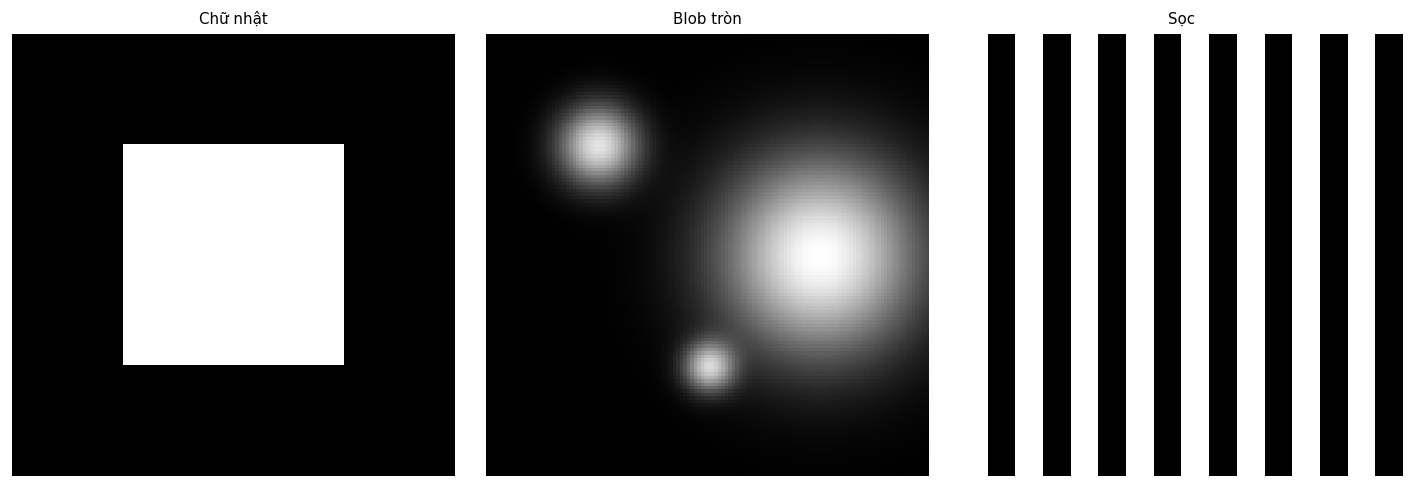

In [3]:
def make_test_image(kind='rect', N=128):
    """Tạo ảnh tổng hợp để thử nghiệm."""
    img = np.zeros((N, N), dtype=np.float64)
    if kind == 'rect':
        img[N//4:3*N//4, N//4:3*N//4] = 1.0
    elif kind == 'circles':
        yy, xx = np.ogrid[:N, :N]
        img += 0.8 * np.exp(-((xx-N//4)**2 + (yy-N//4)**2) / (2*8**2))
        img += 0.9 * np.exp(-((xx-3*N//4)**2 + (yy-N//2)**2) / (2*20**2))
        img += 0.7 * np.exp(-((xx-N//2)**2 + (yy-3*N//4)**2) / (2*5**2))
        img = np.clip(img, 0, 1)
    elif kind == 'stripe':
        for i in range(0, N, 16):
            img[:, i:i+8] = 1.0
    elif kind == 'noise':
        rng = np.random.default_rng(42)
        img = rng.random((N, N))
    return img

def show_images(imgs, titles, cmap='gray', figsize=None):
    n = len(imgs)
    figsize = figsize or (4*n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1: axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(img, cmap=cmap, vmin=img.min(), vmax=img.max())
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Kiểm tra
img_rect    = make_test_image('rect', 128)
img_circles = make_test_image('circles', 128)
img_stripe  = make_test_image('stripe', 128)
show_images([img_rect, img_circles, img_stripe],
            ['Chữ nhật', 'Blob tròn', 'Sọc'])


---
# Bài 1 — Lọc trong miền tần số


## 1.1 Biến đổi Fourier rời rạc 2D (từ đầu)

**Công thức:**
$$F(u,v) = \sum_{x=0}^{M-1}\sum_{y=0}^{N-1} f(x,y)\,e^{-j2\pi\left(\frac{ux}{M}+\frac{vy}{N}\right)}$$

**Yêu cầu:** Cài đặt hàm `my_dft2` và `my_idft2`. Kiểm chứng bằng `np.allclose`.

> **Gợi ý:** DFT 2D = DFT 1D theo từng hàng, rồi DFT 1D theo từng cột kết quả.
> Vectorise bằng broadcasting để tránh 4 vòng lặp lồng nhau.


In [4]:
def my_dft1(x):
    """DFT 1D từ đầu.
    
    Args:
        x: array 1D, độ dài N
    Returns:
        X: array 1D phức, độ dài N
    """
    N = len(x)
    # TODO: cài đặt DFT 1D
    # Gợi ý: tạo ma trận twiddle W[n,k] = exp(-j2pi*n*k/N)
    # rồi X = W @ x

    N = len(x)

    # W[n,k] = exp(-j2pi*n*k/N)
    n = np.arange(N).reshape(1, N)
    k = np.arange(N).reshape(N, 1)

    W = np.exp(-2j * np.pi * k * n / N)

    # X = W @ x
    X = W @ x
    return X

def my_dft2(f):
    """DFT 2D từ đầu bằng cách áp DFT 1D theo hàng rồi cột.
    
    Args:
        f: array 2D thực, kích thước M×N
    Returns:
        F: array 2D phức, kích thước M×N
    """
    # TODO: áp my_dft1 theo từng hàng, sau đó theo từng cột

    # DFT theo tung hang
    temp = np.apply_along_axis(my_dft1, axis=1, arr=f)
    # DFT theo tung cot
    F = np.apply_along_axis(my_dft1, axis=0, arr=temp)

    return F
     

def my_idft2(F):
    """IDFT 2D từ đầu.
    
    Args:
        F: array 2D phức
    Returns:
        f: array 2D thực (lấy phần thực)
    """
    # Gợi ý: IDFT = conjugate(DFT(conjugate(F))) / MN
    # hoặc đổi dấu số mũ trong công thức DFT

    M, N = F.shape

    # IDFT = conjugate(DFT(conjugate(F))) / MN
    f = np.conj(my_dft2(np.conj(F)) / (M*N))

    return np.real(f) 


In [5]:
# Kiểm chứng
f_small = make_test_image('rect', N=16)  # dùng ảnh nhỏ vì DFT naive chậm

F_mine = my_dft2(f_small)
F_numpy = np.fft.fft2(f_small)

print('DFT 2D - allclose:', np.allclose(F_mine, F_numpy, atol=1e-6))

f_recovered = my_idft2(F_mine)
print('IDFT 2D - allclose:', np.allclose(f_small, f_recovered, atol=1e-6))


DFT 2D - allclose: True
IDFT 2D - allclose: True


## 1.2 Hiển thị phổ biên độ và pha

Sau `fftshift`, tần số DC nằm ở trung tâm. Phổ biên độ thường hiển thị dưới dạng log.


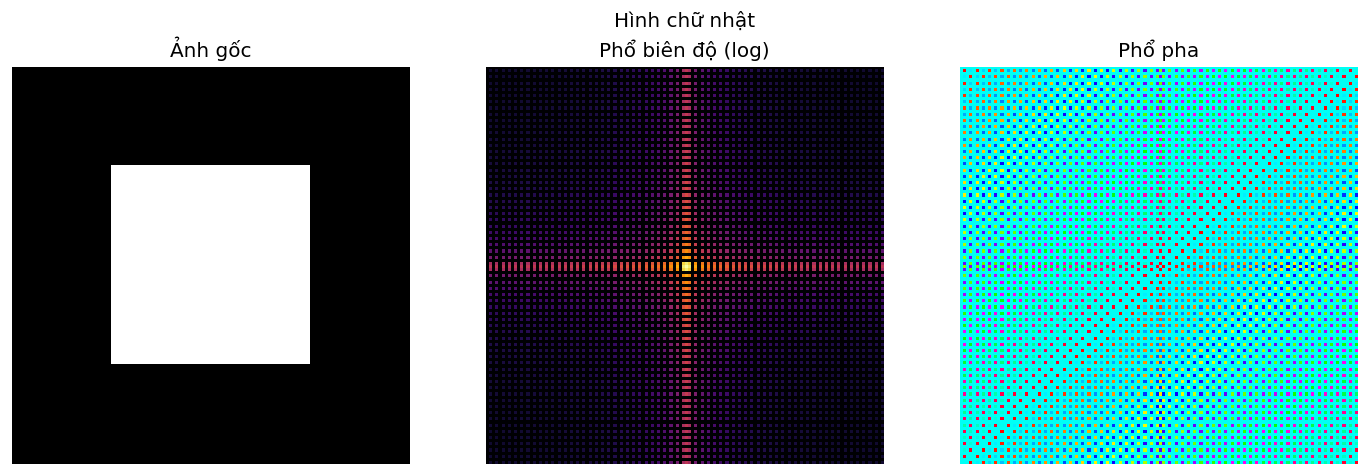

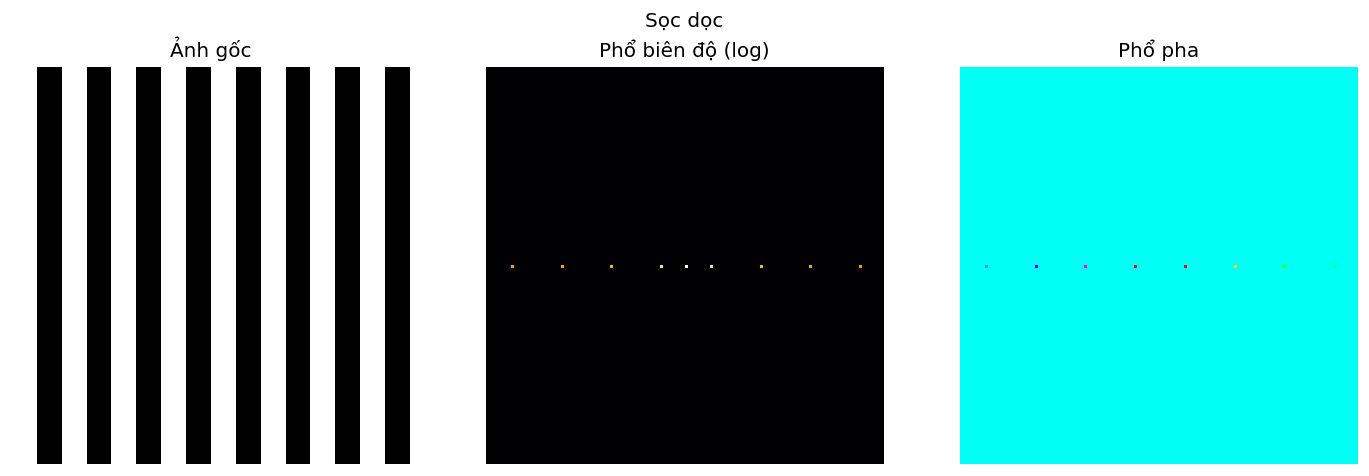

In [6]:
def show_spectrum(f, title=''):
    """Hiển thị ảnh gốc, phổ biên độ (log), và phổ pha."""
    F = np.fft.fftshift(np.fft.fft2(f))
    mag   = np.abs(F)
    phase = np.angle(F)
    log_mag = np.log1p(mag)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(f, cmap='gray'); axes[0].set_title('Ảnh gốc')
    axes[1].imshow(log_mag, cmap='inferno'); axes[1].set_title('Phổ biên độ (log)')
    axes[2].imshow(phase, cmap='hsv'); axes[2].set_title('Phổ pha')
    for ax in axes: ax.axis('off')
    if title: fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_spectrum(img_rect, 'Hình chữ nhật')
show_spectrum(img_stripe, 'Sọc dọc')


## 1.3 Quy trình lọc tổng quát

Mọi bộ lọc đều dùng quy trình: `fft2` → `fftshift` → nhân $H$ → `ifftshift` → `ifft2` → lấy phần thực.


In [7]:
def apply_filter(f, H):
    """Lọc ảnh f với mask H trong miền tần số.
    
    Args:
        f: ảnh 2D, kích thước M×N
        H: mask bộ lọc 2D, kích thước M×N, giá trị trong [0,1]
    Returns:
        g: ảnh đã lọc, kích thước M×N
    """
    # TODO: cài đặt quy trình lọc bốn bước

    # 1. FFT
    F = my_dft2(f)
    # 2. Shift DC vao giua
    F_shift = np.fft.fftshift(F)

    # 3. Nhan H bo loc
    G_shift = F_shift * H

    # 4. Shift nguoc lai
    G = np.fft.ifftshift(G_shift)

    # 5. idft2
    g = my_idft2(G)

    # 6. Lay phan thuc
    g = np.real(g)
  

    return g
    raise NotImplementedError

def freq_coords(M, N):
    """Tính khoảng cách tần số D(u,v) từ DC sau fftshift.
    
    Returns:
        D: array M×N, D[i,j] = sqrt((i-M/2)^2 + (j-N/2)^2)
    """
    u = np.arange(M) - M // 2
    v = np.arange(N) - N // 2
    UU, VV = np.meshgrid(u, v, indexing='ij')
    return np.sqrt(UU**2 + VV**2)


In [8]:
f = make_test_image('rect', N=64)

H = np.ones_like(f)

g = apply_filter(f, H)

print(np.allclose(f, g, atol=1e-6))

True


## 1.4 Lọc lý tưởng (Ideal LP/HP)

$$H_{LP}^{ideal}(u,v) = \begin{cases}1 & D(u,v)\le D_0\\0 & D(u,v)>D_0\end{cases}$$

Quan sát hiện tượng Gibbs (ringing) xung quanh biên sau khi lọc.


In [9]:
def ideal_lp(M, N, D0):
    """Mask lọc thấp lý tưởng."""
    # TODO

    D = freq_coords(M, N)

    H = (D <= D0).astype(np.float64)

    return H
    raise NotImplementedError

def ideal_hp(M, N, D0):
    """Mask lọc cao lý tưởng."""
    # TODO: dùng ideal_lp

    return 1.0 - ideal_lp(M, N, D0)
    raise NotImplementedError


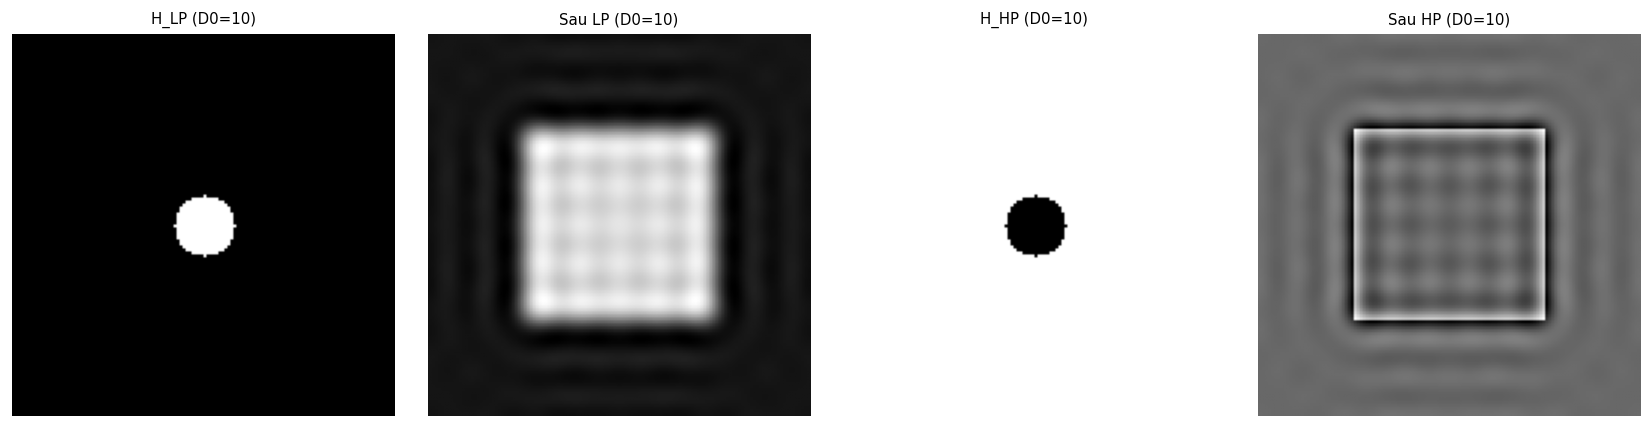

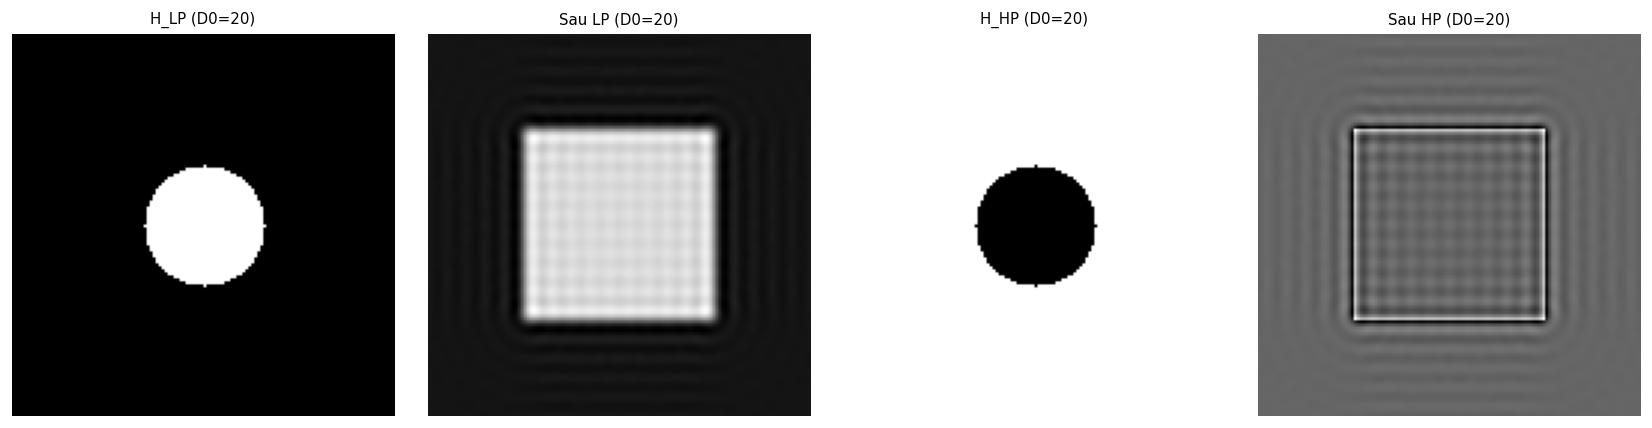

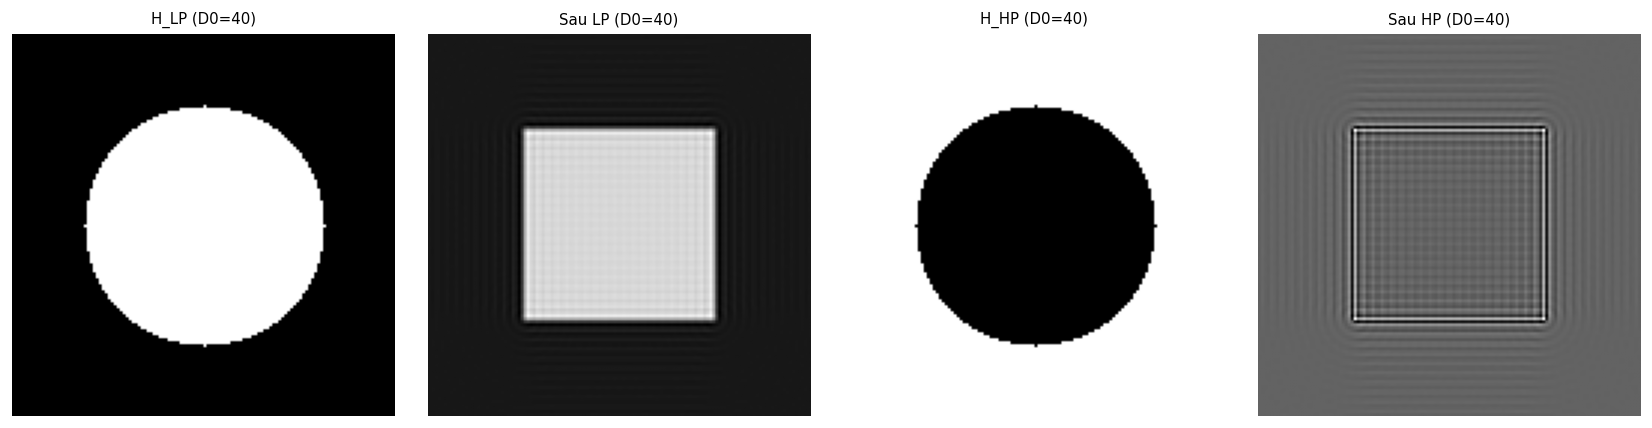

In [10]:
# Thử nghiệm với các D0 khác nhau
M, N = img_rect.shape
for D0 in [10, 20, 40]:
    H_lp = ideal_lp(M, N, D0)
    H_hp = ideal_hp(M, N, D0)
    g_lp = apply_filter(img_rect, H_lp)
    g_hp = apply_filter(img_rect, H_hp)
    show_images(
        [H_lp, g_lp, H_hp, g_hp],
        [f'H_LP (D0={D0})', f'Sau LP (D0={D0})',
         f'H_HP (D0={D0})', f'Sau HP (D0={D0})'],
        figsize=(14, 3.5)
    )


**Giải thích:** (điền vào đây)
- Hiện tượng Gibbs xảy ra khi nào?
    - Hiện tượng Gibbs (Ringing Artifacts - hiện tượng gợn sóng) xảy ra khi bạn sử dụng bộ lọc tần số có sự thay đổi đột ngột (bước nhảy vọt) giữa vùng giữ lại tần số (passband) và vùng chặn tần số (stopband) trong miền tần số, tiêu biểu nhất là bộ lọc Ideal Filter (Bộ lọc lý tưởng).
    - Bản chất toán học: Trong miền tần số, bộ lọc lý tưởng có dạng một hàm xung vuông (mặt cắt hình chữ nhật phẳng có giá trị nhảy từ $1$ xuống $0$ tại vị trí tần số cắt $D_0$).
- D0 ảnh hưởng đến kết quả thế nào?
    - $D_0$ (tần số cắt) đóng vai trò là bán kính quyết định phạm vi tần số được giữ lại hoặc loại bỏ. Sự thay đổi của $D_0$ tác động trái ngược nhau giữa hai bộ lọc:
    - A. Đối với bộ lọc thông thấp (Ideal Lowpass Filter - Lọc nhòe)
        - Khi $D_0$ nhỏ ($D_0 = 10$): Chặn hầu hết tần số cao $\rightarrow$ Ảnh bị nhòe rất nặng; gợn sóng Gibbs xuất hiện dưới dạng các đường vân to, thô quanh biên vật thể.
        - Khi $D_0$ tăng dần ($D_0 = 20 \rightarrow 40$): Cho nhiều tần số cao đi qua hơn $\rightarrow$ Ảnh rõ nét trở lại; các gợn sóng Gibbs mỏng đi, khít lại và thu hẹp sát vào biên cạnh.
    - B. Đối với bộ lọc thông cao (Ideal Highpass Filter - Trích xuất cạnh)
        - Khi $D_0$ nhỏ ($D_0 = 10$): Chỉ chặn một vùng nhỏ tần số thấp tại tâm $\rightarrow$ Giữ lại được hầu hết các cạnh; ảnh có nhiều đường nét rõ ràng, biên cạnh dày và sáng.
        - Khi $D_0$ tăng dần ($D_0 = 20 \rightarrow 40$): Chặn thêm nhiều tần số trung bình và thấp $\rightarrow$ Ảnh kết quả tối dần, các đường biên dày biến mất, chỉ còn lại các nét vẽ viền cực kỳ mảnh, mịn (chi tiết vi mô).


## 1.5 Lọc Butterworth

$$H_{LP}^{BW}(u,v) = \frac{1}{1+\left[D(u,v)/D_0\right]^{2n}}$$

Tại $D=D_0$: $H=0.5$ với mọi $n$. Khi $n\to\infty$ tiệm cận lọc lý tưởng.


In [11]:
def butterworth_lp(M, N, D0, n):
    """Mask lọc thấp Butterworth bậc n."""
    # TODO

    D = freq_coords(M, N)

    H = 1 / (1 + (D / D0) ** (2*n))

    return H
    raise NotImplementedError

def butterworth_hp(M, N, D0, n):
    """Mask lọc cao Butterworth bậc n."""
    # TODO

    H_lp = butterworth_lp(M, N, D0, n)

    H_hp = 1 - H_lp

    return H_hp
    raise NotImplementedError


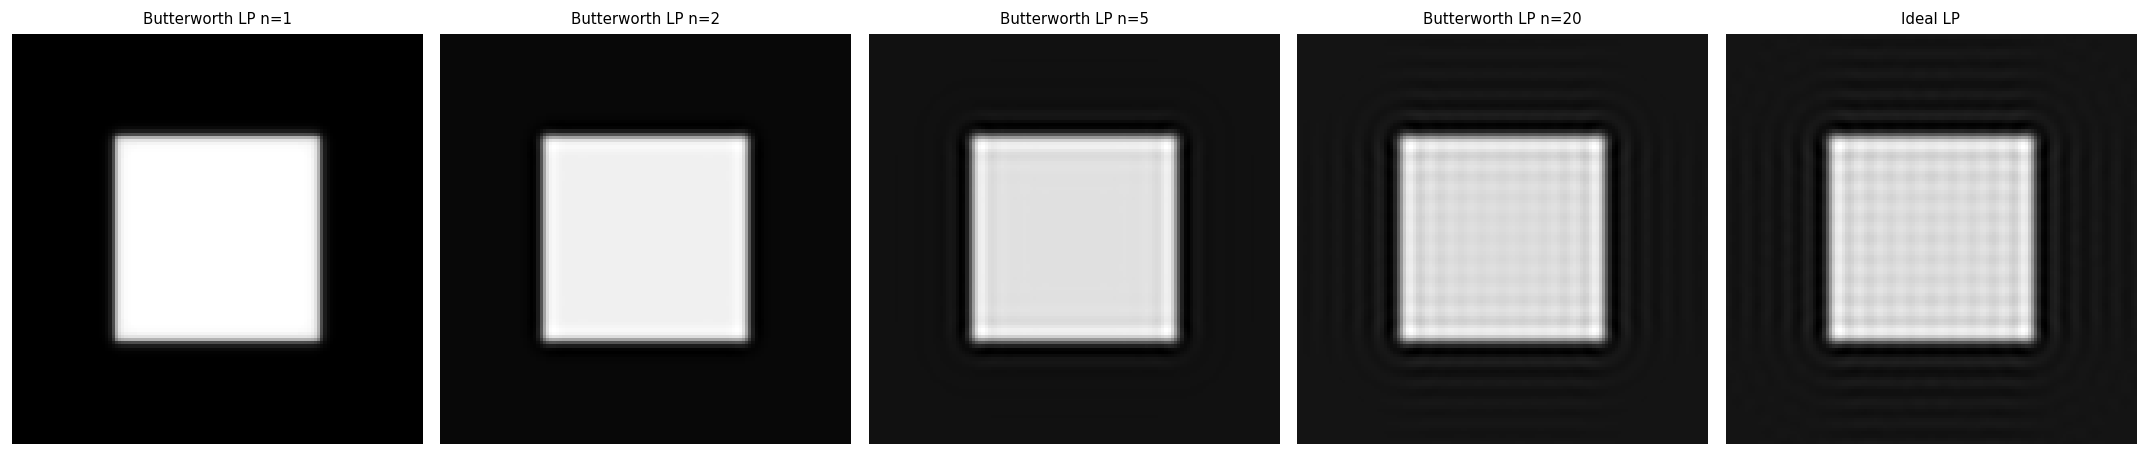

In [12]:
# So sánh Butterworth bậc khác nhau với Ideal
D0, M, N = 20, *img_rect.shape
results = []
titles  = []
for order in [1, 2, 5, 20]:
    H = butterworth_lp(M, N, D0, order)
    results.append(apply_filter(img_rect, H))
    titles.append(f'Butterworth LP n={order}')
results.append(apply_filter(img_rect, ideal_lp(M, N, D0)))
titles.append('Ideal LP')
show_images(results, titles, figsize=(18, 4))


## 1.6 Lọc băng thông (Band-pass)

$$H_{BP}(u,v) = H_{LP}(u,v;\,D_{high}) - H_{LP}(u,v;\,D_{low})$$

Chỉ cho qua tần số trong dải $[D_{low}, D_{high}]$.


In [13]:
def butterworth_bp(M, N, D_low, D_high, n):
    """Mask lọc băng thông Butterworth.
    
    Args:
        D_low:  tần số cắt thấp
        D_high: tần số cắt cao (D_high > D_low)
    """
    # TODO: dùng butterworth_lp

    H_high = butterworth_lp(M, N, D_high, n)
    H_low = butterworth_lp(M, N, D_low, n)

    H_hp = H_high - H_low

    return H_hp
    raise NotImplementedError


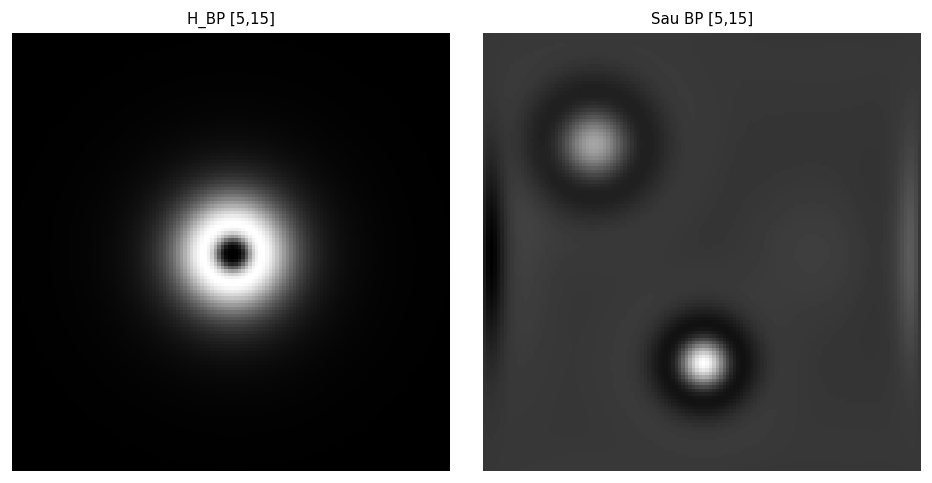

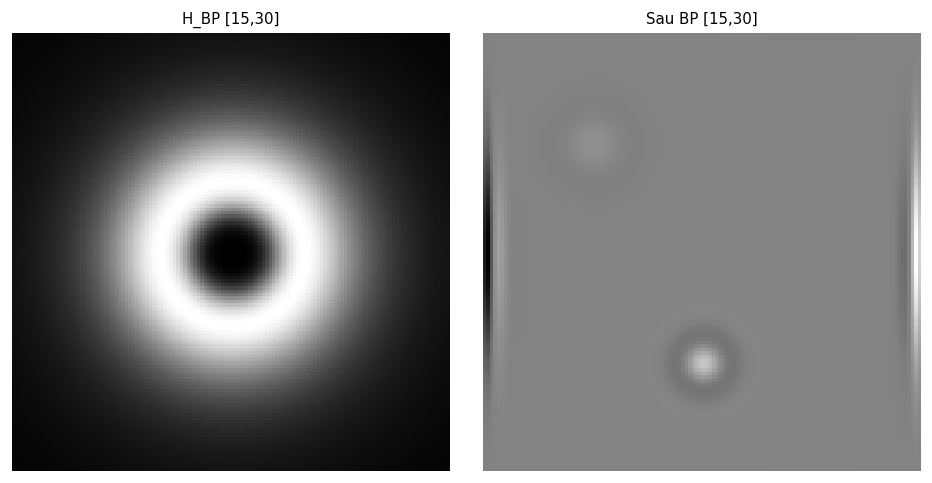

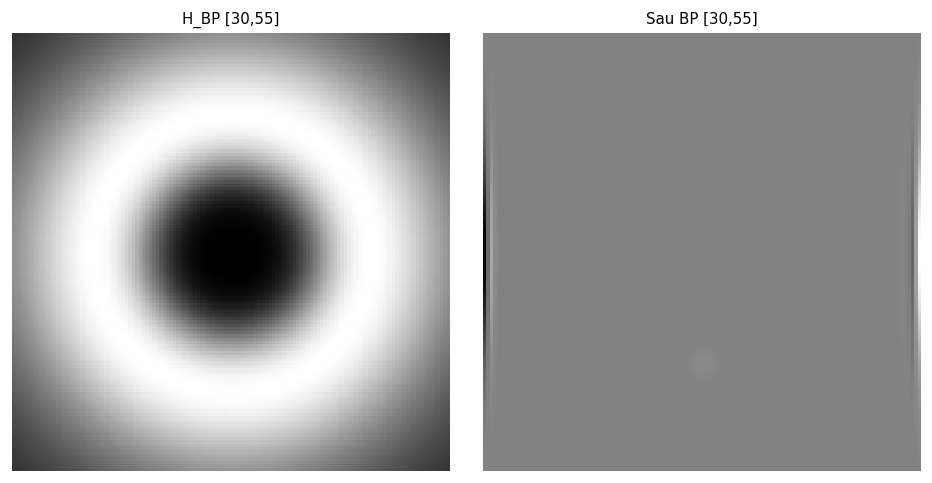

In [14]:
M, N = img_circles.shape
for D_lo, D_hi in [(5, 15), (15, 30), (30, 55)]:
    H = butterworth_bp(M, N, D_lo, D_hi, n=2)
    g = apply_filter(img_circles, H)
    show_images([H, g],
                [f'H_BP [{D_lo},{D_hi}]', f'Sau BP [{D_lo},{D_hi}]'],
                figsize=(8, 4))


## 1.7 Lọc Notch

Chặn một tần số cụ thể $(u_0, v_0)$ và điểm đối xứng $(M/2-u_0, N/2-v_0)$.

**Ứng dụng:** loại bỏ nhiễu tuần hoàn (periodic noise) trong ảnh.


In [15]:
def butterworth_notch(M, N, u0, v0, D0, n):
    """Mask lọc notch Butterworth tại (u0,v0) và điểm đối xứng.
    
    u0, v0: toạ độ notch tính từ DC (trung tâm sau fftshift)
    Ví dụ: u0=10, v0=0 chặn sọc ngang tần số u=10.
    """
    # TODO
    # Lưu ý: xử lý D_k = 0 tại tâm notch (chia cho epsilon)

    eps = 1e-8
    u = np.arange(M) - M // 2
    v = np.arange(N) - N // 2
    UU, VV = np.meshgrid(u, v, indexing='ij')

    # u0 đi với UU (hàng), v0 đi với VV (cột)
    D1 = np.sqrt((UU - u0)**2 + (VV - v0)**2)
    D2 = np.sqrt((UU + u0)**2 + (VV + v0)**2)

    H1 = 1.0 / (1.0 + (D0 / (D1 + eps))**(2 * n))
    H2 = 1.0 / (1.0 + (D0 / (D2 + eps))**(2 * n))

    return H1 * H2


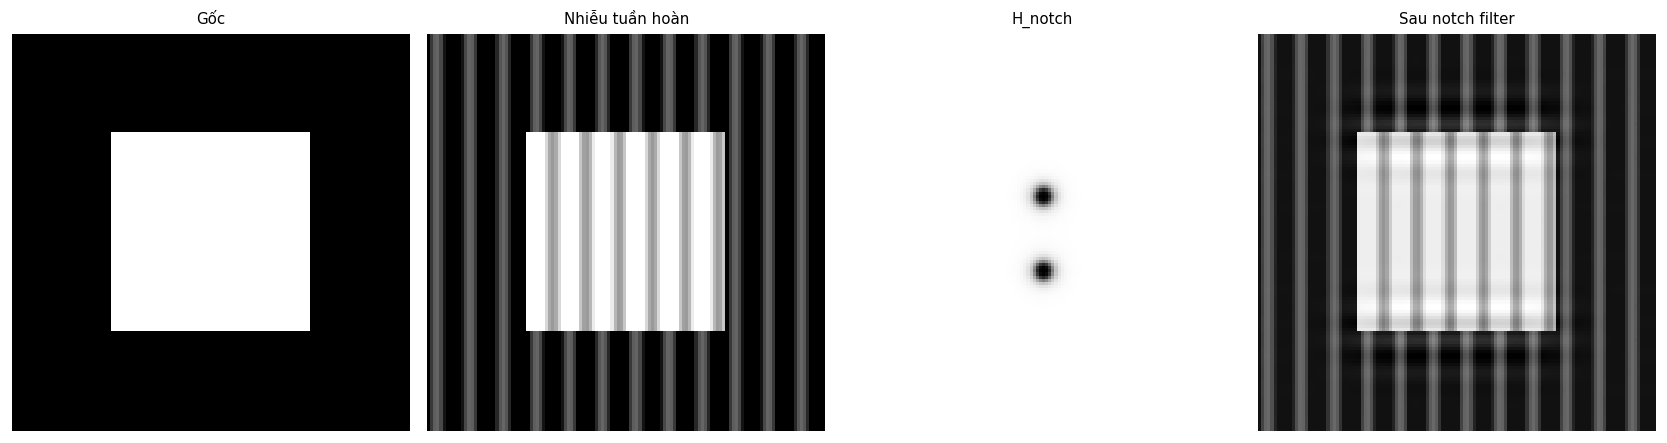

In [16]:
# Tạo ảnh có nhiễu tuần hoàn
def add_periodic_noise(img, u0, v0, amplitude=0.3):
    """Thêm nhiễu tuần hoàn dạng sóng sin 2D."""
    M, N = img.shape
    yy, xx = np.ogrid[:M, :N]
    noise = amplitude * np.sin(2*np.pi*(u0*xx/N + v0*yy/M))
    return np.clip(img + noise, 0, 1)

img_noisy = add_periodic_noise(img_rect, u0=12, v0=0, amplitude=0.4)
M, N = img_noisy.shape

H_notch = butterworth_notch(M, N, u0=12, v0=0, D0=3, n=2)
g_notch  = apply_filter(img_noisy, H_notch)

show_images([img_rect, img_noisy, H_notch, g_notch],
            ['Gốc', 'Nhiễu tuần hoàn', 'H_notch', 'Sau notch filter'],
            figsize=(14, 4))

---
# Bài 2 — Phát hiện đặc trưng


## 2.0 Công cụ gradient (dùng chung)

Kernel Sobel:
$$K_x = \begin{bmatrix}-1&0&+1\\-2&0&+2\\-1&0&+1\end{bmatrix}, \quad
K_y = K_x^\top$$


In [17]:
def sobel_gradients(img):
    """Tính gradient Sobel từ đầu (không dùng cv2 hay scipy.signal).
    
    Returns:
        Ix, Iy: gradient theo x và y, cùng kích thước với img
    """
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    Ky = Kx.T
    # TODO: cài đặt tích chập 3×3 cho Kx và Ky
    # Xử lý biên bằng reflect padding

    # reflect padding
    padded = np.pad(img, ((1,1), (1,1)), mode='reflect')

    M, N = img.shape

    Ix = np.zeros((M, N), dtype=np.float64)
    Iy = np.zeros((M, N), dtype=np.float64)

    # tich chap 3x3
    for i in range(M):
        for j in range(N):
            patch = padded[i:i+3, j:j+3]

            Ix[i, j] = np.sum(patch * Kx)
            Iy[i, j] = np.sum(patch * Ky)
    
    return Ix, Iy
    raise NotImplementedError

def gaussian_kernel_2d(sigma):
    """Tạo kernel Gaussian 2D."""
    r = int(3*sigma + 0.5)
    k = 2*r + 1
    ax = np.arange(-r, r+1, dtype=np.float64)
    xx, yy = np.meshgrid(ax, ax)
    kern = np.exp(-(xx**2 + yy**2) / (2*sigma**2))
    return kern / kern.sum()

def gaussian_blur(img, sigma):
    """Blur ảnh bằng Gaussian từ đầu."""
    kern = gaussian_kernel_2d(sigma)
    # TODO: tích chập img với kern

    kern = gaussian_kernel_2d(sigma)

    kh, kw = kern.shape
    ph, pw = kh//2, kw//2

    #reflect padding
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode='reflect')

    M, N = img.shape

    out = np.zeros((M, N), dtype=np.float64)

    for i in range(M):
        for j in range(N):
            patch = padded[i:i+kh, j:j+kw]

            out[i, j] = np.sum(patch * kern)

    return out

    raise NotImplementedError

def nms_2d(response, window=9, threshold=0.0):
    """Non-Maximum Suppression 2D.
    
    Giữ lại pixel nếu là cực đại cục bộ trong cửa sổ window×window
    VÀ lớn hơn threshold.
    """
    local_max = maximum_filter(response, size=window)
    return (response > threshold) & (response == local_max)


## 2.1 Harris Corner Detector

$$R = \det(M) - k\cdot[\operatorname{tr}(M)]^2 = \lambda_1\lambda_2 - k(\lambda_1+\lambda_2)^2$$

Với $k\in[0.04,0.06]$. $R>0$: góc. $R<0$: cạnh. $|R|\approx0$: phẳng.


In [ ]:
def harris_detector(img, sigma=1.5, k=0.05, threshold_ratio=0.01, nms_window=9):
    """Harris Corner Detector từ đầu.
    
    Args:
        img:             ảnh grayscale float64, giá trị trong [0,1]
        sigma:           độ lệch chuẩn Gaussian cho cửa sổ làm mịn
        k:               tham số Harris (0.04-0.06)
        threshold_ratio: ngưỡng T = threshold_ratio * max(R)
        nms_window:      kích thước cửa sổ NMS
  
    Returns:
        R:        bản đồ phản hồi Harris, kích thước M×N
        corners:  boolean mask, True tại vị trí góc sau NMS
    """
    # Bước 1: Tính gradient
    Ix, Iy = sobel_gradients(img)
    
    # Bước 2: Tính ba ảnh tích
    Ix2 = Ix**2;
    Iy2 = Iy**2;
    Ixy = Ix*Iy
    
    # Bước 3: Làm mịn bằng Gaussian
    Sx2 = gaussian_blur(Ix2, sigma)
    Sy2 = gaussian_blur(Iy2, sigma)
    Sxy = gaussian_blur(Ixy, sigma)
    
    # Bước 4: Tính R
    det_M = Sx2*Sy2 - Sxy**2
    tr_M  = Sx2 + Sy2
    R = det_M - k * tr_M**2
    
    # Bước 5+6: NMS và ngưỡng
    threshold = threshold_ratio * R.max()
    corners = nms_2d(R, nms_window, threshold)
    return R, corners
    # TODO: bỏ comment và hoàn thiện
    raise NotImplementedError


Số góc phát hiện: 4


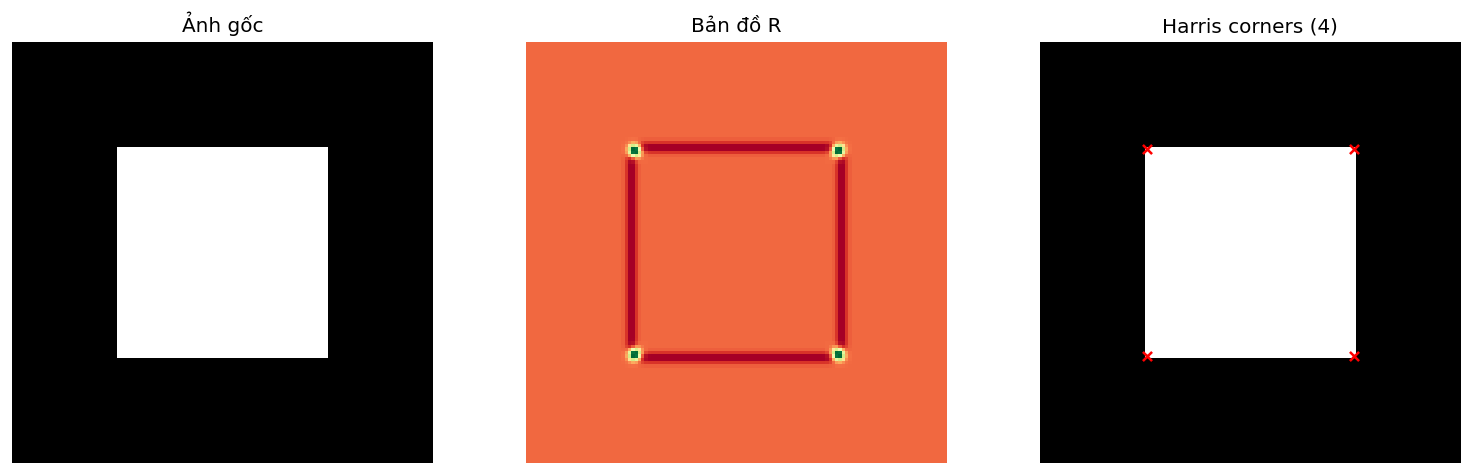

In [19]:
# Ảnh thử nghiệm cho Harris
img_harris_test = make_test_image('rect', N=128)

R, corners = harris_detector(img_harris_test, sigma=1.5, k=0.05,threshold_ratio=0.01, nms_window=9)

ys, xs = np.where(corners)
print(f'Số góc phát hiện: {len(xs)}')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img_harris_test, cmap='gray'); axes[0].set_title('Ảnh gốc')
axes[1].imshow(R, cmap='RdYlGn'); axes[1].set_title('Bản đồ R')
axes[2].imshow(img_harris_test, cmap='gray')
axes[2].scatter(xs, ys, s=30, c='red', marker='x', linewidths=1.5)
axes[2].set_title(f'Harris corners ({len(xs)})')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


In [20]:
# Thử nghiệm ảnh hưởng của tham số k và sigma
# TODO: chạy harris_detector với k = 0.02, 0.05, 0.10 và so sánh số góc
for k_val in [0.02, 0.05, 0.10]:
    R, corners = harris_detector(
        img_harris_test,
        sigma=1.5,
        k=k_val,
        threshold_ratio=0.01,
        nms_window=9
    )
    print(f'k = {k_val:.2f}: {corners.sum()} corners')
      
      # TODO


k = 0.02: 4 corners
k = 0.05: 4 corners
k = 0.10: 4 corners


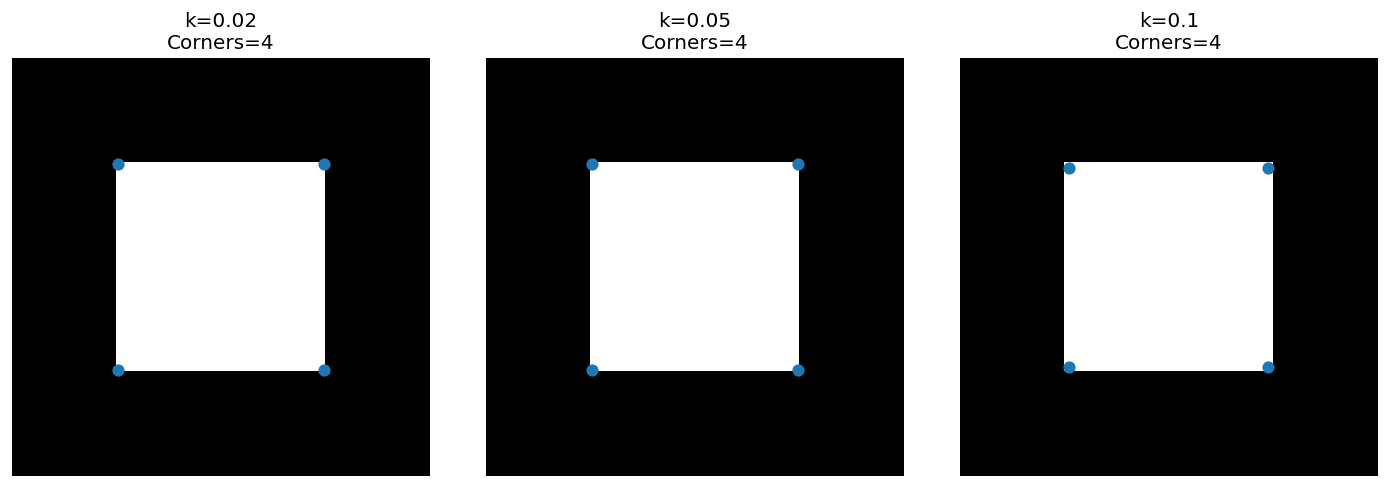

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, k_val in zip(axes, [0.02, 0.05, 0.10]):

    R, corners = harris_detector(
        img_rect,
        sigma=1.5,
        k=k_val,
        threshold_ratio=0.01,
        nms_window=9
    )

    ax.imshow(img_rect, cmap='gray')

    ys, xs = np.where(corners)
    ax.scatter(xs, ys, s=40)

    ax.set_title(
        f'k={k_val}\nCorners={corners.sum()}'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2.2 Harris-Laplace

Kết hợp Harris (phát hiện góc) với phân tích thang đo qua LoG chuẩn hoá:
$$\sigma^* = \arg\max_\sigma |\sigma^2 \nabla^2 L(\mathbf{x},\sigma)|$$

Xấp xỉ LoG bằng DoG: $\sigma^2 \nabla^2 L \approx \frac{1}{k-1}[L(k\sigma) - L(\sigma)]$


In [22]:
def harris_laplace(img, sigmas=None, k=0.05, threshold_ratio=0.01):
    """Harris-Laplace: phát hiện góc bất biến thang đo.
    
    Args:
        img:    ảnh grayscale float64
        sigmas: danh sách các thang đo, ví dụ [1.0, 1.6, 2.5, 4.0, 6.4]
        k:      tham số Harris
        threshold_ratio: ngưỡng phản hồi Harris
    
    Returns:
        keypoints: list of (row, col, sigma_star)
    """
    if sigmas is None:
        sigmas = [1.0, 1.6, 2.5, 4.0, 6.4]
    
    # Bước 1: Xây dựng scale space — blur ảnh tại mỗi sigma
    # L[i] = gaussian_blur(img, sigmas[i])
    L=[]
    for sigma in sigmas:
        L.append(gaussian_blur(img, sigma))
    
    # Bước 2: Tính Harris response tại mỗi thang
    # R[i], _ = harris_detector(img, sigma=sigmas[i], ...)
    R_list = []
    corners_list = []

    for sigma in sigmas:
        R, corners = harris_detector(img, sigma=sigma, k=k, threshold_ratio=threshold_ratio)
        R_list.append(R)
        corners_list.append(corners)  


    # Bước 3: Tính LoG chuẩn hoá xấp xỉ bằng DoG
    # ratio k_ratio = sigmas[i+1] / sigmas[i]
    # LoG_norm[i] = (L[i+1] - L[i]) / (k_ratio - 1)
    # (cần align index: tính tại sigmas[i] dùng L[i] và L[i+1])
    LoG_norm =[]
    for i in range(len(sigmas) - 1):
        k_ratio = sigmas[i + 1] / sigmas[i]
        DoG = (L[i+1] - L[i]) / (k_ratio - 1)
        LoG_norm.append(np.abs(DoG))
    
    # Bước 4: Với mỗi pixel có Harris response lớn,
    # tìm sigma* = argmax_sigma |LoG_norm| theo chiều sigma
    # Giữ lại nếu sigma* là cực đại cục bộ (không phải edge của dãy sigma)
    keypoints = []

    for i in range(1, len(sigmas) - 1):
        rows, cols = np.where(corners_list[i])

        for r, c in zip(rows, cols):
            responses = []

            for j in range(len(LoG_norm)):
                responses.append(LoG_norm[j][r,c])
            
            responses = np.array(responses)
            best_idx = np.argmax(responses)

            # Bo scale bien
            if 0 < best_idx < len(sigmas) - 1:
                keypoints.append((r, c, sigmas[best_idx]))

    return keypoints
    
    # TODO
    raise NotImplementedError


Số keypoints Harris-Laplace: 8


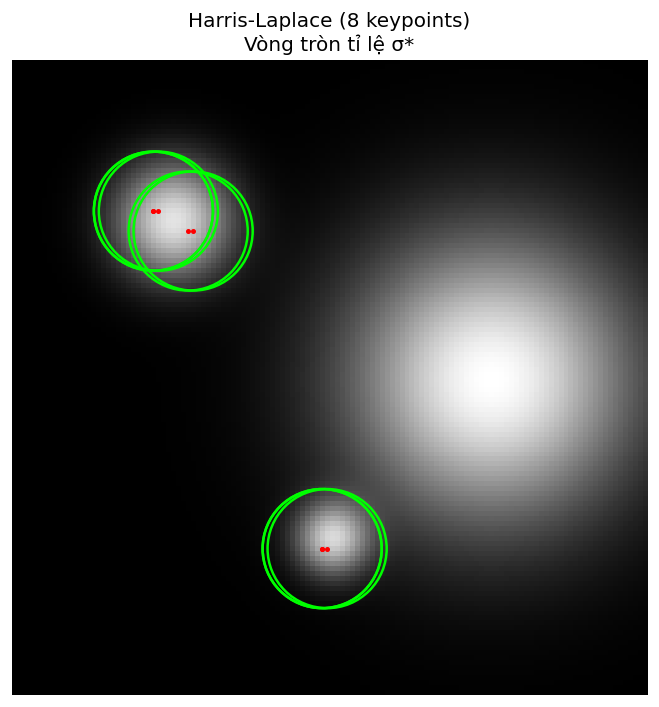

In [23]:
# Thử nghiệm Harris-Laplace
img_hl = make_test_image('circles', N=128)

kps = harris_laplace(img_hl, sigmas=[1.0, 1.6, 2.5, 4.0, 6.4])
print(f'Số keypoints Harris-Laplace: {len(kps)}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_hl, cmap='gray')
for (r, c, s) in kps:
    circle = plt.Circle((c, r), radius=3*s, fill=False, color='lime', linewidth=1.5)
    ax.add_patch(circle)
    ax.plot(c, r, 'r.', markersize=4)
ax.set_title(f'Harris-Laplace ({len(kps)} keypoints)\nVòng tròn tỉ lệ σ*')
ax.axis('off'); plt.tight_layout(); plt.show()


In [24]:
# So sánh Harris chuẩn vs Harris-Laplace khi ảnh bị thu nhỏ
from scipy.ndimage import zoom as sp_zoom

img_full = make_test_image('circles', N=128)
img_half = np.clip(sp_zoom(img_full, 0.5), 0, 1)

# TODO: chạy Harris và Harris-Laplace trên cả hai ảnh
# So sánh: Harris-Laplace có phát hiện được cùng keypoints không?
# Harris thường

R_full, corners_full = harris_detector(
    img_full,
    sigma=1.5,
    k=0.05
)

R_half, corners_half = harris_detector(
    img_half,
    sigma=1.5,
    k=0.05
)

print("Harris:")
print("  Full image :", corners_full.sum(), "corners")
print("  Half image :", corners_half.sum(), "corners")


# Harris-Laplace

kps_full = harris_laplace(
    img_full,
    sigmas=[1.0, 1.6, 2.5, 4.0, 6.4]
)

kps_half = harris_laplace(
    img_half,
    sigmas=[1.0, 1.6, 2.5, 4.0, 6.4]
)

print("\nHarris-Laplace:")
print("  Full image :", len(kps_full), "keypoints")
print("  Half image :", len(kps_half), "keypoints")


Harris:
  Full image : 3 corners
  Half image : 2 corners

Harris-Laplace:
  Full image : 8 keypoints
  Half image : 8 keypoints


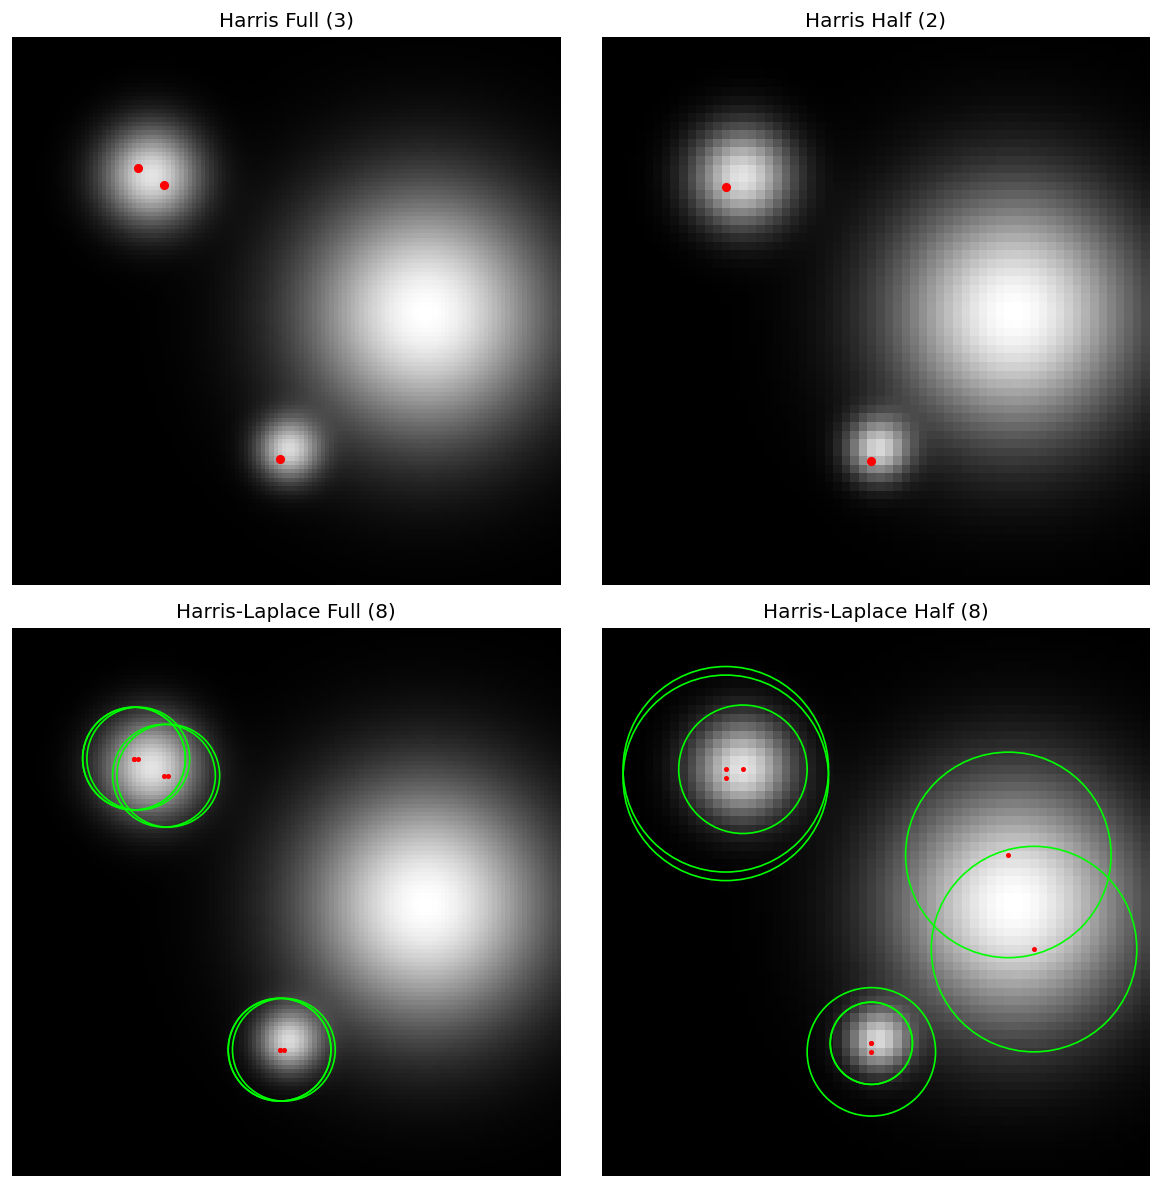

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))

# Harris full
ax[0,0].imshow(img_full, cmap='gray')
ys, xs = np.where(corners_full)
ax[0,0].scatter(xs, ys, s=20, c='r')
ax[0,0].set_title(f'Harris Full ({corners_full.sum()})')
ax[0,0].axis('off')

# Harris half
ax[0,1].imshow(img_half, cmap='gray')
ys, xs = np.where(corners_half)
ax[0,1].scatter(xs, ys, s=20, c='r')
ax[0,1].set_title(f'Harris Half ({corners_half.sum()})')
ax[0,1].axis('off')

# Harris-Laplace full
ax[1,0].imshow(img_full, cmap='gray')
for r, c, s in kps_full:
    ax[1,0].plot(c, r, 'r.', markersize=4)
    ax[1,0].add_patch(
        plt.Circle((c, r), 3*s,
                   fill=False, color='lime')
    )
ax[1,0].set_title(f'Harris-Laplace Full ({len(kps_full)})')
ax[1,0].axis('off')

# Harris-Laplace half
ax[1,1].imshow(img_half, cmap='gray')
for r, c, s in kps_half:
    ax[1,1].plot(c, r, 'r.', markersize=4)
    ax[1,1].add_patch(
        plt.Circle((c, r), 3*s,
                   fill=False, color='lime')
    )
ax[1,1].set_title(f'Harris-Laplace Half ({len(kps_half)})')
ax[1,1].axis('off')

plt.tight_layout()
plt.show()

## 2.3 FAST — Features from Accelerated Segment Test

Pixel $p$ là góc nếu tồn tại cung $n=12$ pixel liên tiếp trên vòng tròn Bresenham bán kính 3,
tất cả đều sáng hơn $I_p + t$ hoặc tối hơn $I_p - t$.

**Kiểm tra nhanh:** Chỉ kiểm tra pixel 1, 5, 9, 13 trước — nếu $<3$ pixel thoả thì bỏ ngay.


In [26]:
# 16 pixel trên vòng tròn Bresenham bán kính 3 (theo thứ tự)
CIRCLE_16 = np.array([
    ( 0, 3),( 1, 3),( 2, 2),( 3, 1),
    ( 3, 0),( 3,-1),( 2,-2),( 1,-3),
    ( 0,-3),(-1,-3),(-2,-2),(-3,-1),
    (-3, 0),(-3, 1),(-2, 2),(-1, 3)
])  # offset (dy, dx)

# Bốn pixel kiểm tra nhanh (vị trí 0, 4, 8, 12 trong CIRCLE_16)
FAST4 = [0, 4, 8, 12]

def fast_is_corner(img, r, c, t, n=12):
    """Kiểm tra pixel (r,c) có phải góc FAST không.
    
    Args:
        img: ảnh grayscale float64 hoặc uint8
        r, c: toạ độ pixel
        t:    ngưỡng
        n:    độ dài cung tối thiểu (mặc định 12)
    
    Returns:
        is_corner: bool
        score:     độ dài cung lớn nhất (dùng cho NMS)
    """
    
    Ip = img[r, c]
    
    # Lấy 16 pixel vòng tròn theo ma trận của thầy
    circle = np.array([img[r + dy, c + dx] for dy, dx in CIRCLE_16])

    # Quick test    
    # circle[FAST4] sẽ lấy nhanh 4 pixel tại vị trí 0, 4, 8, 12
    v4 = circle[FAST4]
    brighter = np.sum(v4 > (Ip + t))
    darker   = np.sum(v4 < (Ip - t))
    
    if brighter < 3 and darker < 3:
        return False, 0
    
    # Full FAST 
    bright_mask = (circle > (Ip + t)).astype(int)
    dark_mask = (circle < (Ip - t)).astype(int)

    # Nối vòng mảng số nguyên (0 và 1)
    bright_ext = np.concatenate([bright_mask, bright_mask[:n-1]])
    dark_ext = np.concatenate([dark_mask, dark_mask[:n-1]])

    max_run = 0

    # Cung sáng dài nhất
    run = 0
    for v in bright_ext:
        if v == 1: 
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    
    # Cung tối dài nhất
    run = 0 
    for v in dark_ext:
        if v == 1: 
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    
    is_corner = (max_run >= n)

    return is_corner, max_run

def fast_detector(img, t=20, n=12, nms=True, nms_window=7):
    """FAST corner detector từ đầu.
    
    Args:
        img:        ảnh grayscale, float64 trong [0,1] hoặc uint8 [0,255]
        t:          ngưỡng (nếu img float: t nên trong [0,1])
        n:          độ dài cung tối thiểu
        nms:        có áp NMS không
        nms_window: kích thước cửa sổ NMS
    
    Returns:
        keypoints: list of (row, col)
        score_map: bản đồ điểm số (0 nếu không phải góc)
    """
    img_calc = img.astype(np.float64)
    
    if img.max() <= 1.0:
        img_calc = img_calc * 255.0
    
    H, W = img.shape
    score_map = np.zeros((H, W), dtype=np.float64)

    # Duyệt qua tất cả pixel, bỏ qua biên (bán kính 3)
    for r in range(3, H-3):
        for c in range(3, W-3):
            is_c, score = fast_is_corner(img_calc, r, c, t, n)
            if is_c:
                score_map[r, c] = score
    
    if nms:
        # threshold=0.1 giúp loại bỏ tất cả các pixel nền có score = 0
        keep = nms_2d(score_map, window=nms_window, threshold=0.1)
        keypoints = list(zip(*np.where(keep)))
    else:
        # Nếu không áp dụng NMS, chỉ lấy những vị trí có score > 0
        keypoints = list(zip(*np.where(score_map > 0)))
    
    return keypoints, score_map

Số keypoints FAST: 37


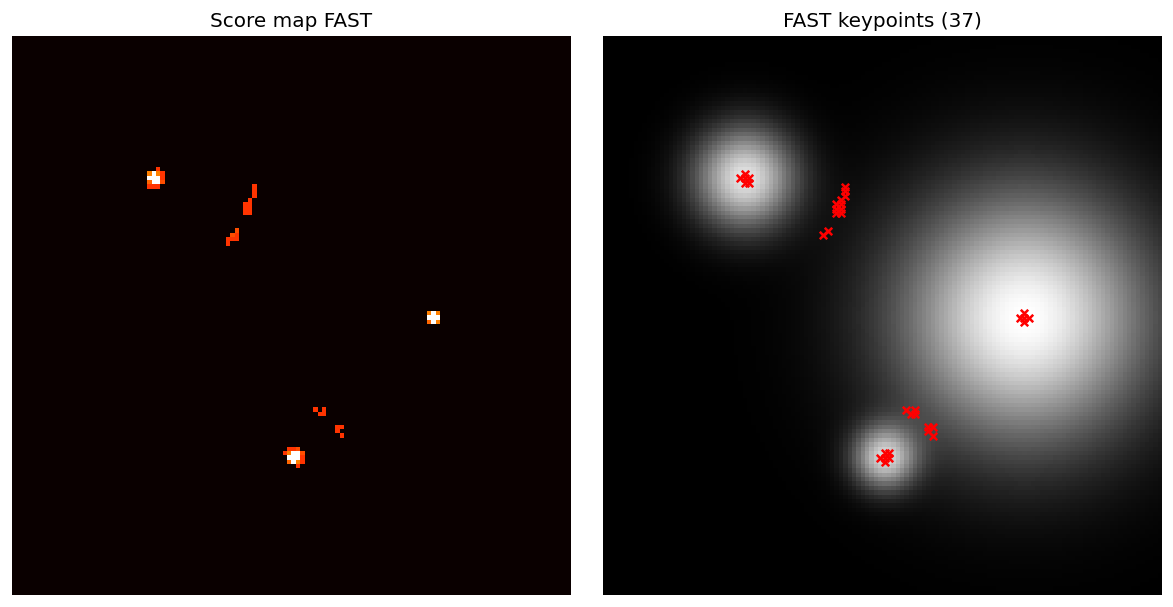

In [27]:
# Ảnh thử nghiệm FAST
img = make_test_image('circles', 128)

kps_fast, smap = fast_detector(img, t=0.1, n=12, nms=True)
print(f'Số keypoints FAST: {len(kps_fast)}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(smap, cmap='hot'); axes[0].set_title('Score map FAST')
axes[1].imshow(img, cmap='gray')
if kps_fast:
    ys, xs = zip(*kps_fast)
    axes[1].scatter(xs, ys, s=20, c='red', marker='x')
axes[1].set_title(f'FAST keypoints ({len(kps_fast)})')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


In [28]:
# Thử nghiệm: thay đổi ngưỡng t
for t_val in [0.05, 0.10, 0.20, 0.35]:
    kps, _ = fast_detector(img, t=t_val, n=12)
    print(f't={t_val:.2f}: {len(kps)} keypoints')


t=0.05: 38 keypoints
t=0.10: 37 keypoints
t=0.20: 29 keypoints
t=0.35: 28 keypoints


## 2.4 So sánh ba phương pháp (Được phép dùng AI để hỗ trợ, nhưng phải nêu được ý tưởng chính)

Chạy Harris, Harris-Laplace, và FAST trên cùng ảnh. So sánh:
1. Số keypoints phát hiện
2. Phân bố không gian
3. Độ ổn định khi xoay ảnh


In [29]:
from scipy.ndimage import rotate
import numpy as np
import matplotlib.pyplot as plt

# Ảnh gốc và ảnh xoay
img = make_test_image('circles', 128)

img_rot = rotate(
    img,
    angle=45,
    reshape=False,
    order=1
)

# ==================================
# Harris
# ==================================
R, corners = harris_detector(
    img,
    sigma=1.5,
    k=0.04,
    threshold_ratio=0.01,
    nms_window=9
)

kp_harris = list(zip(*np.where(corners)))

R_rot, corners_rot = harris_detector(
    img_rot,
    sigma=1.5,
    k=0.04,
    threshold_ratio=0.01,
    nms_window=9
)

kp_harris_rot = list(zip(*np.where(corners_rot)))

# ==================================
# Harris-Laplace
# ==================================
kp_hl = harris_laplace(
    img,
    sigmas=[1.0, 1.6, 2.5, 4.0, 6.4],
    threshold_ratio=0.01
)

kp_hl_rot = harris_laplace(
    img_rot,
    sigmas=[1.0, 1.6, 2.5, 4.0, 6.4],
    threshold_ratio=0.01
)

# chỉ lấy tọa độ để vẽ
kp_hl_xy = [(r, c) for r, c, s in kp_hl]
kp_hl_rot_xy = [(r, c) for r, c, s in kp_hl_rot]

# ==================================
# FAST
# ==================================
kp_fast, smap = fast_detector(
    img,
    t=0.1,
    n=12,
    nms=True
)

kp_fast_rot, smap_rot = fast_detector(
    img_rot,
    t=0.1,
    n=12,
    nms=True
)

# ==================================
# Thống kê
# ==================================
print("===== ORIGINAL =====")
print("Harris       :", len(kp_harris))
print("HarrisLaplace:", len(kp_hl))
print("FAST         :", len(kp_fast))

print("\n===== ROTATED =====")
print("Harris       :", len(kp_harris_rot))
print("HarrisLaplace:", len(kp_hl_rot))
print("FAST         :", len(kp_fast_rot))

===== ORIGINAL =====
Harris       : 2
HarrisLaplace: 8
FAST         : 37

===== ROTATED =====
Harris       : 5
HarrisLaplace: 12
FAST         : 39


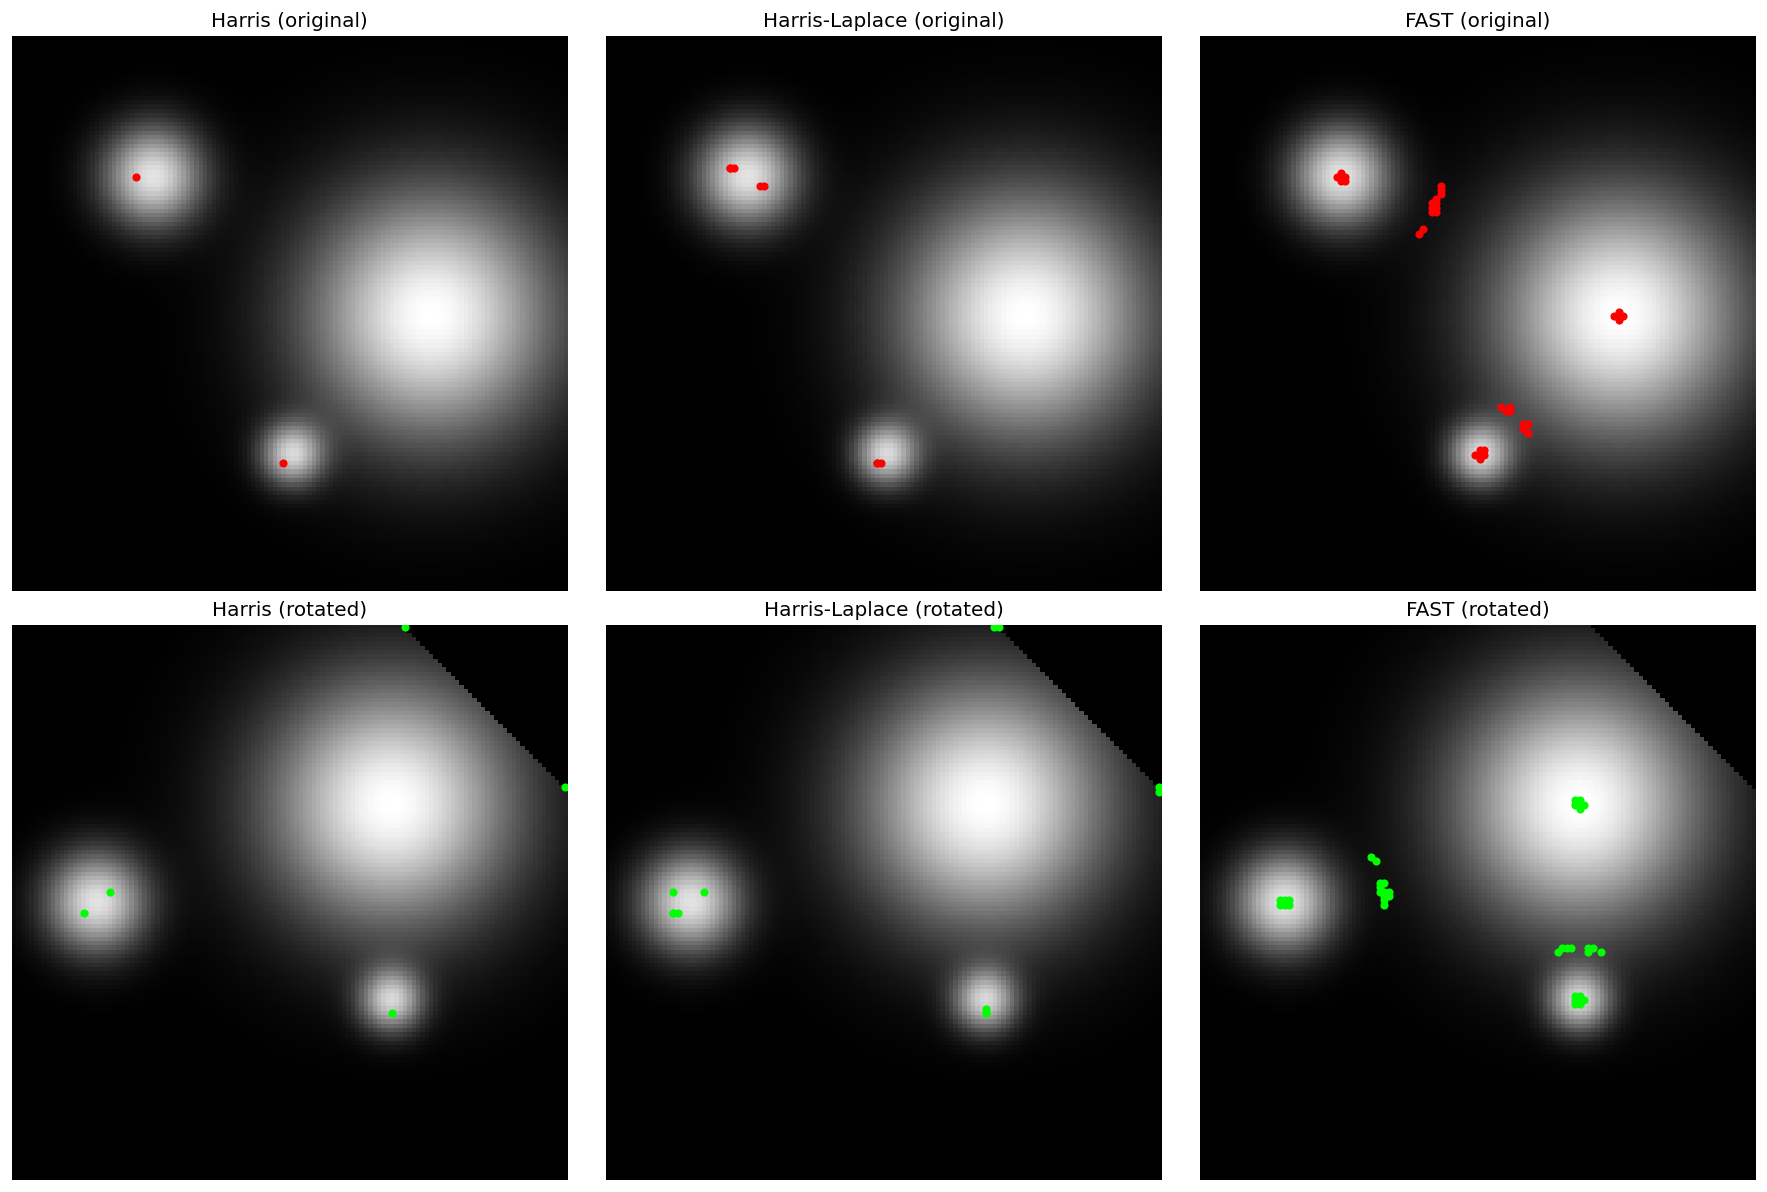

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

methods = [
    ("Harris", kp_harris, kp_harris_rot),
    ("Harris-Laplace", kp_hl_xy, kp_hl_rot_xy),
    ("FAST", kp_fast, kp_fast_rot)
]

for i, (name, kp1, kp2) in enumerate(methods):

    axes[0, i].imshow(img, cmap='gray')

    if len(kp1):
        ys, xs = zip(*kp1)
        axes[0, i].scatter(xs, ys, s=15, c='red')

    axes[0, i].set_title(f"{name} (original)")
    axes[0, i].axis('off')

    axes[1, i].imshow(img_rot, cmap='gray')

    if len(kp2):
        ys, xs = zip(*kp2)
        axes[1, i].scatter(xs, ys, s=15, c='lime')

    axes[1, i].set_title(f"{name} (rotated)")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

---
# Bài 3 — Simplified SIFT

**Pipeline:**
1. Xây dựng DoG pyramid (scale space + DoG)
2. Tìm cực trị 26 lân cận → keypoint ứng viên
3. Lọc tương phản thấp
4. Gán hướng chủ đạo $\theta^*$ (histogram 36 bin)
5. Xây dựng descriptor 32D ($2\times2\times8$, nearest-neighbor)
6. Kiểm chứng bất biến góc quay và thang đo

> **Lưu ý:** Bỏ qua tinh chỉnh Taylor (Bước 2a), lọc cạnh Hessian (Bước 2c),
> bilinear interpolation (dùng nearest-neighbor), keypoint phụ (Bước 3b).


## 3.0 Ảnh thử nghiệm cho SIFT


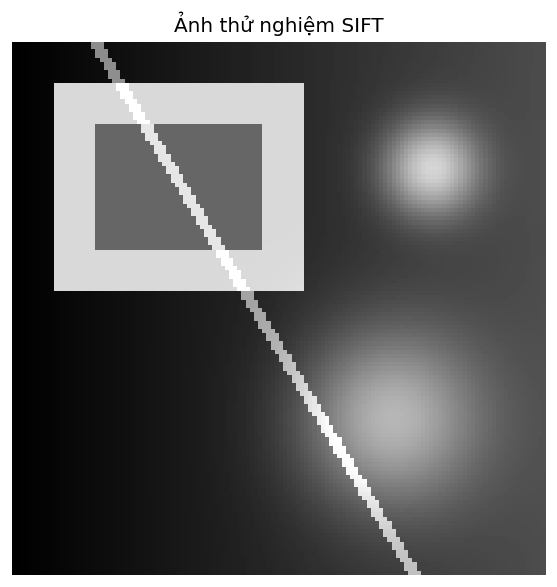

In [31]:
def make_sift_test_image(N=128):
    """Ảnh tổng hợp có nhiều cấu trúc ở nhiều kích thước khác nhau."""
    img = np.zeros((N, N), dtype=np.float64)
    # Gradient nền nhẹ
    img += np.linspace(0, 0.3, N)[np.newaxis, :]
    # Hình chữ nhật lớn
    img[10:60, 10:70] = 0.85
    img[20:50, 20:60] = 0.40
    # Đường chéo
    for i in range(N):
        j = int(i * 0.6 + 20)
        if 0 <= j < N:
            img[i, max(0,j-1):min(N,j+2)] = min(1.0, img[i,j] + 0.5)
    # Blob nhỏ
    yy, xx = np.ogrid[:N, :N]
    img += 0.6 * np.exp(-((xx-100)**2 + (yy-30)**2) / (2*8**2))
    img += 0.5 * np.exp(-((xx-90)**2 + (yy-90)**2) / (2*15**2))
    return np.clip(img, 0, 1)

img_sift = make_sift_test_image(128)
plt.figure(figsize=(5,5))
plt.imshow(img_sift, cmap='gray'); plt.title('Ảnh thử nghiệm SIFT'); plt.axis('off')
plt.tight_layout(); plt.show()


## 3.1 Scale Space và DoG Pyramid

**Scale space:** $L(x,y,\sigma) = G_\sigma * f$

**Tính chất nửa nhóm:** $G_{\sigma_1} * G_{\sigma_2} = G_{\sqrt{\sigma_1^2+\sigma_2^2}}$

Thay vì blur từ ảnh gốc tại mỗi $\sigma$, blur từ tầng trước với $\sigma_\Delta = \sqrt{\sigma_{i+1}^2 - \sigma_i^2}$.

**DoG:** $D(x,y,\sigma_i) = L(x,y,k\sigma_i) - L(x,y,\sigma_i)$

DoG xấp xỉ LoG chuẩn hoá thang đo và rẻ vì kim tự tháp Gaussian đã phải tính.


In [32]:
from scipy.ndimage import gaussian_filter
def build_dog_pyramid(img, n_octaves=3, n_scales=3, sigma0=1.6):
    """Xây dựng kim tự tháp Gaussian và DoG.
    
    Args:
        img:       ảnh float64 [0,1], kích thước H×W
        n_octaves: số octave
        n_scales:  số tầng hữu dụng mỗi octave (s=3 theo Lowe)
        sigma0:    sigma gốc (1.6 theo Lowe)
    
    Returns:
        gaussians: list[n_octaves][n_scales+3] — ảnh Gaussian
        dogs:      list[n_octaves][n_scales+2] — ảnh DoG
        sigmas:    list[n_octaves][n_scales+3] — sigma tương ứng
    """
    k = 2 ** (1.0 / n_scales)  # tỉ lệ sigma giữa hai tầng liên tiếp
    n_layers = n_scales + 3    # số ảnh Gaussian mỗi octave
    
    gaussians = []
    dogs      = []
    sigmas_all = []
    
    base = img.astype(np.float64)

    for o in range(n_octaves):

        octave_gaussians = []
        octave_sigmas = []

        # Gaussian images
        for s in range(n_layers):

            sigma = sigma0 * (k ** s)

            G = gaussian_filter(
                base,
                sigma=sigma,
                mode='reflect'
            )

            octave_gaussians.append(G)
            octave_sigmas.append(sigma)

        # DoG images
        octave_dogs = []

        for s in range(n_layers - 1):
            D = octave_gaussians[s + 1] - octave_gaussians[s]
            octave_dogs.append(D)

        gaussians.append(octave_gaussians)
        dogs.append(octave_dogs)
        sigmas_all.append(octave_sigmas)

        # Downsample cho octave tiếp theo
        if o < n_octaves - 1:
            base = octave_gaussians[n_scales][::2, ::2]        
    
    return gaussians, dogs, sigmas_all


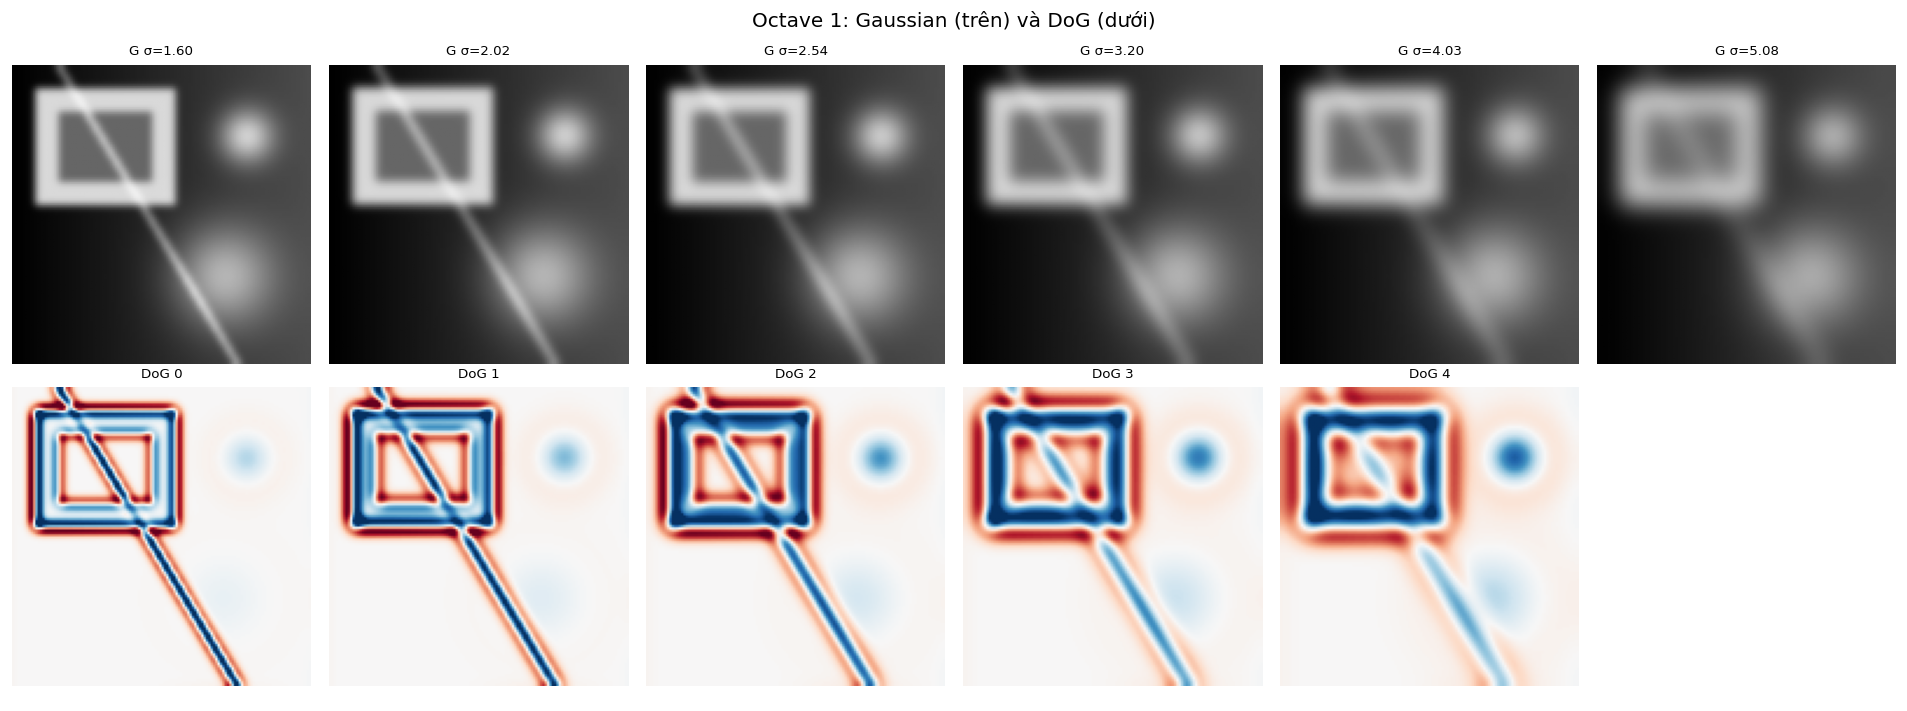

Octave 1: 128×128 pixel, 6 Gaussian, 5 DoG
Octave 2: 64×64 pixel, 6 Gaussian, 5 DoG
Octave 3: 32×32 pixel, 6 Gaussian, 5 DoG


In [33]:
# Kiểm tra và visualise pyramid
gaussians, dogs, sigmas = build_dog_pyramid(img_sift, n_octaves=3, n_scales=3, sigma0=1.6)

# Hiển thị octave đầu: Gaussian + DoG
if gaussians[0] and dogs[0]:
    n_g = len(gaussians[0])
    n_d = len(dogs[0])
    fig, axes = plt.subplots(2, max(n_g, n_d), figsize=(16, 6))
    for i, (g, s) in enumerate(zip(gaussians[0], sigmas[0])):
        axes[0, i].imshow(g, cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f'G σ={s:.2f}', fontsize=8); axes[0, i].axis('off')
    for i, d in enumerate(dogs[0]):
        vm = np.percentile(np.abs(d), 98) + 1e-8
        axes[1, i].imshow(d, cmap='RdBu_r', vmin=-vm, vmax=vm)
        axes[1, i].set_title(f'DoG {i}', fontsize=8); axes[1, i].axis('off')
    # Tắt axes thừa
    for j in range(n_d, max(n_g, n_d)):
        axes[1, j].axis('off')
    plt.suptitle('Octave 1: Gaussian (trên) và DoG (dưới)')
    plt.tight_layout(); plt.show()

    # Kiểm tra kích thước qua các octave
    for oct_idx in range(len(gaussians)):
        if gaussians[oct_idx]:
            h, w = gaussians[oct_idx][0].shape
            print(f'Octave {oct_idx+1}: {h}×{w} pixel, '
                  f'{len(gaussians[oct_idx])} Gaussian, {len(dogs[oct_idx])} DoG')


## 3.2 Phát hiện cực trị 26 lân cận

Một pixel $(x_0, y_0)$ trong tầng DoG giữa là ứng viên keypoint nếu $D(x_0,y_0,\sigma_0)$
lớn hơn (hoặc nhỏ hơn) tất cả 26 lân cận: 8 cùng tầng + 9 tầng trên + 9 tầng dưới.

Sau đó lọc: chỉ giữ nếu $|D(x_0,y_0,\sigma_0)| \ge \tau_c = 0.03$.


In [34]:
def find_dog_extrema(dogs, sigmas, tau_c=0.03, border=5):
    """Tìm cực trị cục bộ trong 26 lân cận của DoG pyramid.
    
    Args:
        dogs:   list[n_octaves][n_layers] — ảnh DoG
        sigmas: list[n_octaves][n_layers] — sigma tương ứng Gaussian
        tau_c:  ngưỡng tương phản tối thiểu
        border: số pixel bỏ qua ở biên
    
    Returns:
        keypoints: list of dict với keys:
                   'oct'   — chỉ số octave
                   'layer' — chỉ số tầng DoG (tầng giữa)
                   'r', 'c' — toạ độ trong octave đó
                   'sigma' — sigma* của keypoint
                   'dog_val' — giá trị DoG tại keypoint
    """
    keypoints = []
    
    for oct_idx, oct_dogs in enumerate(dogs):
        # Duyệt qua các tầng giữa (không phải tầng đầu và cuối)
        for layer in range(1, len(oct_dogs) - 1):
            D_prev = oct_dogs[layer - 1]  # tầng dưới
            D_curr = oct_dogs[layer]       # tầng hiện tại
            D_next = oct_dogs[layer + 1]   # tầng trên
            H, W   = D_curr.shape

            for r in range(border, H - border):
                for c in range(border, W - border):

                    center = D_curr[r, c]

                    # lọc tương phản thấp trước cho nhanh
                    if abs(center) < tau_c:
                        continue

                    cube = np.stack([
                        D_prev[r-1:r+2, c-1:c+2],
                        D_curr[r-1:r+2, c-1:c+2],
                        D_next[r-1:r+2, c-1:c+2]
                    ])

                    neighbors = cube.reshape(-1)

                    # phần tử trung tâm trong khối 3×3×3
                    center_idx = 13

                    neighbors = np.delete(neighbors, center_idx)

                    is_max = center > np.max(neighbors)
                    is_min = center < np.min(neighbors)

                    if is_max or is_min:

                        keypoints.append({
                            'oct'     : oct_idx,
                            'layer'   : layer,
                            'r'       : r,
                            'c'       : c,
                            'sigma'   : sigmas[oct_idx][layer],
                            'dog_val' : float(center)
                        })

    
    return keypoints


Số keypoints sau lọc tương phản: 24


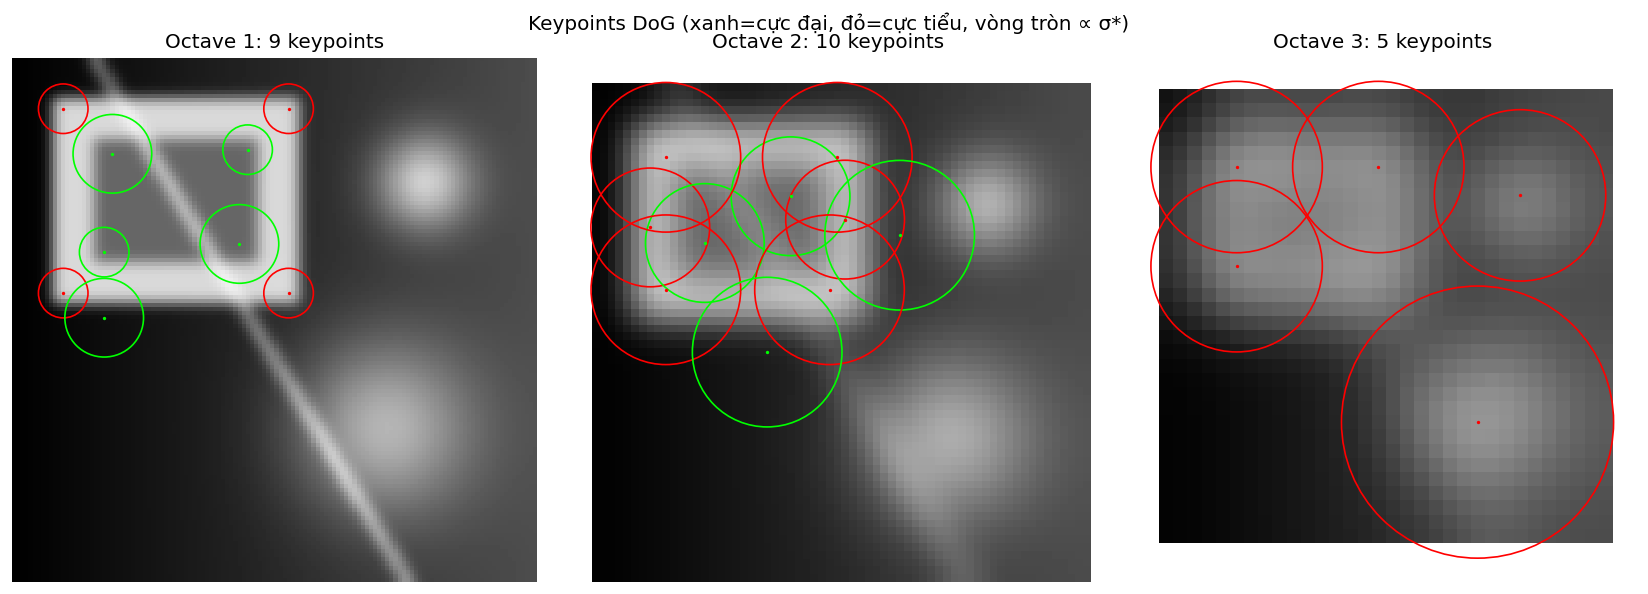

In [35]:
keypoints = find_dog_extrema(dogs, sigmas, tau_c=0.03)
print(f'Số keypoints sau lọc tương phản: {len(keypoints)}')

# Visualise keypoints với vòng tròn tỉ lệ sigma*
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for oct_idx in range(min(3, len(gaussians))):
    if not gaussians[oct_idx]: continue
    ax = axes[oct_idx]
    ax.imshow(gaussians[oct_idx][0], cmap='gray', vmin=0, vmax=1)
    kps_oct = [kp for kp in keypoints if kp['oct'] == oct_idx]
    for kp in kps_oct:
        c = plt.Circle((kp['c'], kp['r']),
                        radius=3*kp['sigma'], fill=False,
                        color='lime' if kp['dog_val']>0 else 'red',
                        linewidth=1.0)
        ax.add_patch(c)
        ax.plot(kp['c'], kp['r'], '.', color='lime' if kp['dog_val']>0 else 'red', ms=2)
    ax.set_title(f'Octave {oct_idx+1}: {len(kps_oct)} keypoints')
    ax.axis('off')
plt.suptitle('Keypoints DoG (xanh=cực đại, đỏ=cực tiểu, vòng tròn ∝ σ*)')
plt.tight_layout(); plt.show()


## 3.3 Gán hướng chủ đạo $\theta^*$

Tại thang $\sigma^*$, tính gradient trong vùng bán kính $r = 4.5\sigma^*$ quanh keypoint.
Xây dựng histogram 36 bin với trọng số = biên độ gradient $\times$ Gaussian $\sigma_w = 1.5\sigma^*$.
$\theta^*$ = bin cao nhất.

**Quan trọng:** gradient phải tính từ $L(\cdot, \sigma^*)$, không phải ảnh gốc.


In [ ]:
def assign_orientations(keypoints, gaussians, sigmas, n_bins=36):
    """Gán hướng chủ đạo cho mỗi keypoint.
    
    Args:
        keypoints: list of dicts từ find_dog_extrema
        gaussians: kim tự tháp Gaussian
        sigmas:    sigma tương ứng
        n_bins:    số bin histogram (36 theo Lowe)
    
    Returns:
        keypoints_with_orient: list of dicts, thêm key 'theta' (degrees)
    """
    bin_width = 360.0 / n_bins  # 10 degrees per bin
    result = []
    
    for kp in keypoints:
        oct_idx = kp['oct']
        layer   = kp['layer']
        r0, c0  = kp['r'], kp['c']
        sigma_s = kp['sigma']  #
        theta_star = 0.0 
        #TO DO
        L = gaussians[oct_idx][layer]

        H, W = L.shape

        radius = int(round(4.5 * sigma_s))
        sigma_w = 1.5 * sigma_s

        histogram = np.zeros(n_bins, dtype=np.float64)

        r_min = max(radius, r0 - radius)
        r_max = min(H - radius - 1, r0 + radius)

        c_min = max(radius, c0 - radius)
        c_max = min(W - radius - 1, c0 + radius)

        for r in range(r_min, r_max + 1):
            for c in range(c_min, c_max + 1):

                dy = r - r0
                dx = c - c0

                if dx*dx + dy*dy > radius*radius:
                    continue

                # Central difference
                gx = L[r, c + 1] - L[r, c - 1]
                gy = L[r - 1, c] - L[r + 1, c]

                magnitude = np.sqrt(gx*gx + gy*gy)

                angle = np.degrees(np.arctan2(gy, gx))
                angle = angle % 360.0

                gaussian_weight = np.exp(
                    -(dx*dx + dy*dy) /
                    (2 * sigma_w * sigma_w)
                )

                vote = magnitude * gaussian_weight

                bin_idx = int(angle // bin_width)
                bin_idx = min(bin_idx, n_bins - 1)

                histogram[bin_idx] += vote

        max_bin = np.argmax(histogram)

        theta_star = (max_bin + 0.5) * bin_width
              #lấy từ histogram
        
        result.append({**kp, 'theta': theta_star, 'histogram': histogram})
    
    return result


Keypoints với hướng: 24


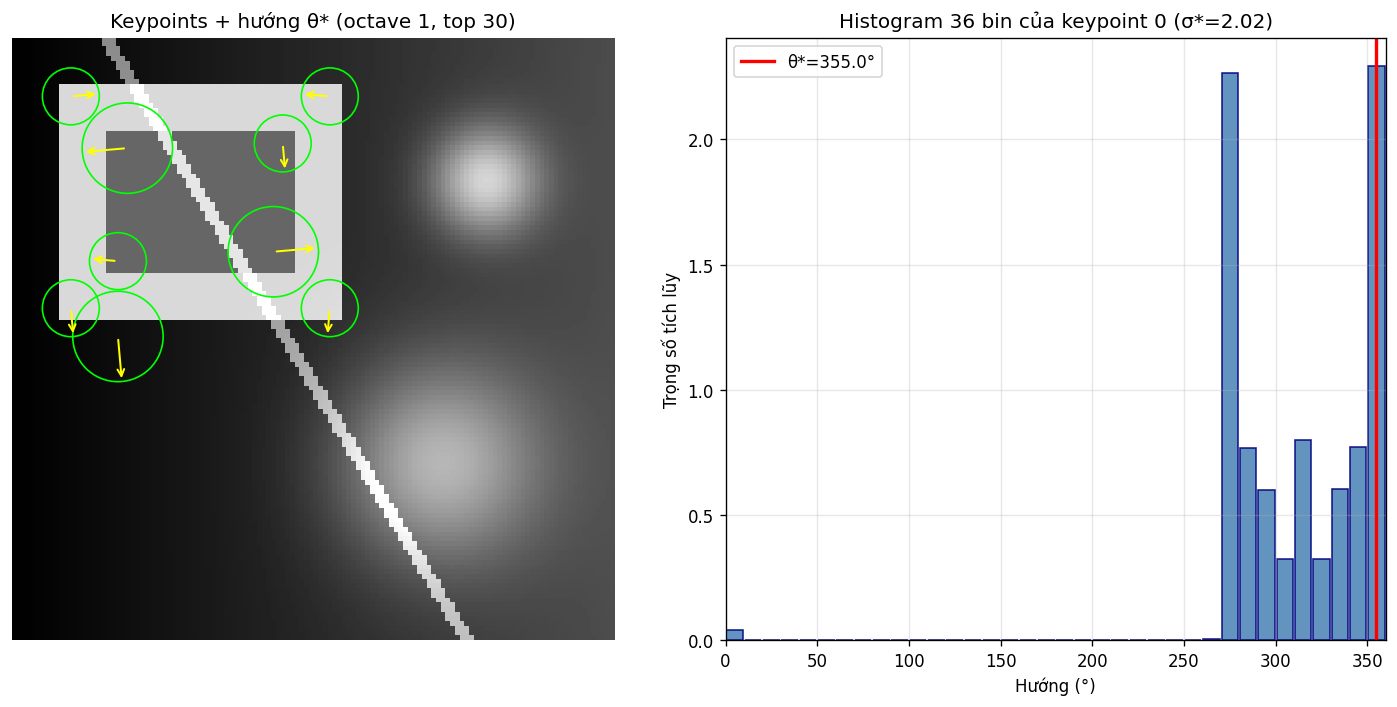

In [37]:
keypoints_oriented = assign_orientations(keypoints, gaussians, sigmas)
print(f'Keypoints với hướng: {len(keypoints_oriented)}')

# Visualise vài keypoint với hướng
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes[0]
ax.imshow(img_sift, cmap='gray', vmin=0, vmax=1)

# Chỉ vẽ keypoints octave 0 để dễ nhìn
kps_oct0 = [kp for kp in keypoints_oriented if kp['oct'] == 0]
for kp in kps_oct0[:30]:  # top 30
    r, c, s, th = kp['r'], kp['c'], kp['sigma'], kp['theta']
    circle = plt.Circle((c, r), 3*s, fill=False, color='lime', lw=1)
    ax.add_patch(circle)
    # Vẽ mũi tên hướng
    dx = 3*s * np.cos(np.radians(th))
    dy = 3*s * np.sin(np.radians(th))
    ax.annotate('', xy=(c+dx, r+dy), xytext=(c, r),
                arrowprops=dict(arrowstyle='->', color='yellow', lw=1.2))
ax.set_title(f'Keypoints + hướng θ* (octave 1, top 30)')
ax.axis('off')

# Histogram hướng của một keypoint
if kps_oct0:
    kp = kps_oct0[0]
    hist = kp['histogram']
    bins_deg = np.arange(36) * 10 + 5
    axes[1].bar(bins_deg, hist, width=9, color='steelblue', edgecolor='navy', alpha=0.85)
    axes[1].axvline(kp['theta'], color='red', lw=2, label=f"θ*={kp['theta']:.1f}°")
    axes[1].set_xlabel('Hướng (°)'); axes[1].set_ylabel('Trọng số tích lũy')
    axes[1].set_title(f"Histogram 36 bin của keypoint 0 (σ*={kp['sigma']:.2f})")
    axes[1].legend(); axes[1].set_xlim(0, 360); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 3.4 Xây dựng Descriptor 32D

Descriptor mô tả vùng $8\times8$ pixel trong **hệ toạ độ cục bộ** xoay theo $\theta^*$, chuẩn hoá theo $\sigma^*$.

**Hệ toạ độ cục bộ:** pixel tại lưới $(i,j)$ tương ứng toạ độ ảnh:
$$\begin{bmatrix}x\\y\end{bmatrix} = \begin{bmatrix}x_0\\y_0\end{bmatrix} + \sigma^* R_{\theta^*} \begin{bmatrix}i\\j\end{bmatrix}$$

Dùng **nearest-neighbor**: làm tròn $(x,y)$ về pixel gần nhất.

Chia $8\times8$ thành lưới $2\times2$ ô ($4\times4$ pixel mỗi ô) → 4 histogram 8 bin → vector 32D → chuẩn hoá L2.


In [38]:
def compute_descriptors(keypoints_oriented, gaussians, sigmas,
                         grid_size=2, patch_per_cell=4, n_bins=8):
    """Xây dựng descriptor 32D cho mỗi keypoint.
    
    Args:
        keypoints_oriented: list of dicts với 'theta', 'sigma', 'r', 'c', 'oct', 'layer'
        gaussians:          kim tự tháp Gaussian
        sigmas:             sigma tương ứng
        grid_size:          số ô mỗi chiều (2 → lưới 2×2)
        patch_per_cell:     số pixel cục bộ mỗi ô mỗi chiều (4)
        n_bins:             số bin histogram hướng (8 → 45°/bin)
    
    Returns:
        descriptors: np.ndarray shape (K, grid_size^2 * n_bins)
                     = (K, 32) với grid_size=2, n_bins=8
    """
    half = grid_size * patch_per_cell // 2  # = 4: vùng [-4,3] cục bộ
    bin_width = 360.0 / n_bins              # = 45 degrees
    desc_dim  = grid_size * grid_size * n_bins  # = 32
    
    descriptors = []
    
    for kp in keypoints_oriented:
        oct_idx = kp['oct']
        layer   = kp['layer']
        r0, c0  = kp['r'], kp['c']
        sigma_s = kp['sigma']
        theta   = kp['theta']  # degrees
        
        # Ảnh Gaussian tại thang sigma*
        L = gaussians[oct_idx][min(layer + 1, len(gaussians[oct_idx]) - 1)]
        H, W = L.shape
        
        cos_t = np.cos(np.radians(theta))
        sin_t = np.sin(np.radians(theta))
        
        # Khởi tạo lưới histogram: shape (grid_size, grid_size, n_bins)
        grid_hist = np.zeros((grid_size, grid_size, n_bins))
        
        # Duyệt qua tất cả pixel trong vùng [-half, half-1] × [-half, half-1] cục bộ
        for i in range(-half, half):
            for j in range(-half, half):
                # TODO:
                # Toạ độ ảnh sau khi scale và rotate
                x = c0 + sigma_s * (cos_t * j - sin_t * i)
                y = r0 + sigma_s * (sin_t * j + cos_t * i)

                x = int(round(x))
                y = int(round(y))

                # Bỏ qua nếu ra ngoài ảnh
                if x <= 0 or x >= W - 1 or y <= 0 or y >= H - 1:
                    continue

                # Gradient (central difference)
                gx = L[y, x + 1] - L[y, x - 1]
                gy = L[y - 1, x] - L[y + 1, x]

                magnitude = np.sqrt(gx * gx + gy * gy)

                angle = np.degrees(np.arctan2(gy, gx))
                angle = (angle - theta) % 360.0

                # Xác định cell trong lưới 2×2
                cell_r = (i + half) // patch_per_cell
                cell_c = (j + half) // patch_per_cell

                if (cell_r < 0 or cell_r >= grid_size or
                    cell_c < 0 or cell_c >= grid_size):
                    continue

                # Histogram bin
                bin_idx = int(angle // bin_width)
                bin_idx = min(bin_idx, n_bins - 1)

                grid_hist[cell_r, cell_c, bin_idx] += magnitude
        
        desc = grid_hist.reshape(-1)

        norm = np.linalg.norm(desc)
        if norm > 1e-12:
            desc = desc / norm
        descriptors.append(desc)
    
    return np.array(descriptors) if descriptors else np.zeros((0, desc_dim))


Descriptor matrix shape: (24, 32)
Norm của descriptor đầu tiên: 1.0000 (phải ≈ 1.0)


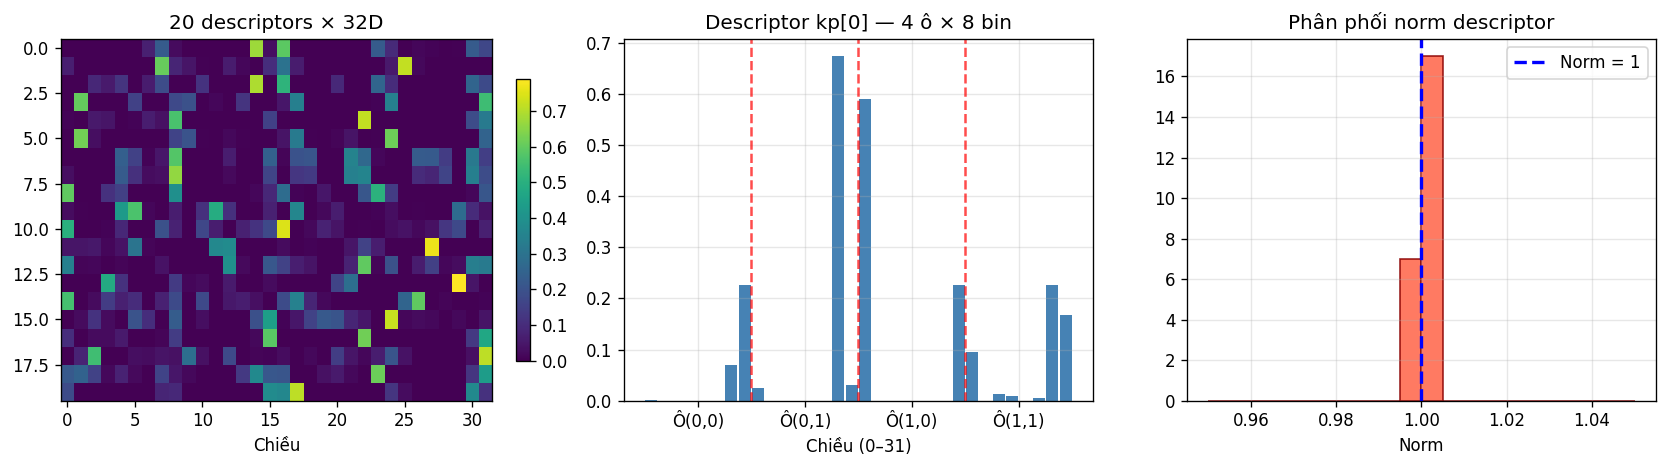

In [39]:
descriptors = compute_descriptors(keypoints_oriented, gaussians, sigmas)
print(f'Descriptor matrix shape: {descriptors.shape}')
print(f'Norm của descriptor đầu tiên: {np.linalg.norm(descriptors[0]):.4f} (phải ≈ 1.0)')

# Visualise descriptor
if len(descriptors) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # Heatmap ma trận descriptor
    n_show = min(20, len(descriptors))
    im = axes[0].imshow(descriptors[:n_show], cmap='viridis', aspect='auto')
    axes[0].set_title(f'{n_show} descriptors × 32D'); axes[0].set_xlabel('Chiều')
    plt.colorbar(im, ax=axes[0], fraction=0.03)
    
    # Bar chart descriptor đầu tiên
    axes[1].bar(range(32), descriptors[0], color='steelblue', width=0.9)
    for b in range(1, 4):  # ranh giới 4 ô
        axes[1].axvline(b*8 - 0.5, color='red', lw=1.5, ls='--', alpha=0.7)
    axes[1].set_title('Descriptor kp[0] — 4 ô × 8 bin')
    axes[1].set_xlabel('Chiều (0–31)'); axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks([3.5, 11.5, 19.5, 27.5])
    axes[1].set_xticklabels(['Ô(0,0)', 'Ô(0,1)', 'Ô(1,0)', 'Ô(1,1)'])
    
    # Phân phối norm
    norms = np.linalg.norm(descriptors, axis=1)
    axes[2].hist(norms, bins=np.linspace(0.95, 1.05, 21), color='tomato', edgecolor='darkred', alpha=0.85)
    axes[2].set_title('Phân phối norm descriptor'); axes[2].set_xlabel('Norm')
    axes[2].axvline(1.0, color='blue', lw=2, ls='--', label='Norm = 1')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout(); plt.show()


## 3.5 Kiểm chứng tính bất biến (cho phép dùng AI để hỗ trợ lập trình phần này, nhưng phải nêu được ý tưởng)

### 3.5a Bất biến góc quay
Tính descriptor của cùng cấu trúc trong ảnh gốc và ảnh xoay. Khoảng cách Euclid giữa hai descriptor phải nhỏ hơn đáng kể so với khoảng cách giữa hai keypoints ngẫu nhiên.


In [40]:
from scipy.ndimage import rotate
import numpy as np
# Tạo ảnh xoay
img_rot = rotate(
    img_sift,
    angle=45,
    reshape=False,
    mode='reflect'
)

# Chạy toàn bộ pipeline
g2, d2, s2 = build_dog_pyramid(img_rot)

kp2 = find_dog_extrema(d2, s2)

kp2_oriented = assign_orientations(
    kp2, g2, s2
)

desc2 = compute_descriptors(
    kp2_oriented, g2, s2
)

In [41]:
# Lấy một keypoint từ ảnh gốc
idx1 = 0

desc_a = descriptors[idx1]

# Tìm descriptor gần nhất trong ảnh xoay
dists = np.linalg.norm(desc2 - desc_a, axis=1)

best_idx = np.argmin(dists)

same_dist = dists[best_idx]

# Khoảng cách ngẫu nhiên
rand_idx = np.random.randint(len(desc2))

random_dist = np.linalg.norm(
    desc_a - desc2[rand_idx]
)

In [42]:
print("Distance (matching structure):", same_dist)
print("Distance (random descriptor):", random_dist)

Distance (matching structure): 0.7886383884328148
Distance (random descriptor): 0.7886383884328148


### 3.5b Bất biến thang đo
Tính descriptor trên ảnh phóng to $1.5\times$. Descriptor của cùng cấu trúc vật lý phải tương tự nhau.


In [43]:
from scipy.ndimage import zoom
import numpy as np

In [44]:
# Tạo ảnh scale 1.5×
img_scale = zoom(img_sift, 1.5, order=1)

# Chạy lại pipeline
g3, d3, s3 = build_dog_pyramid(img_scale)

kp3 = find_dog_extrema(d3, s3)

kp3_oriented = assign_orientations(
    kp3, g3, s3
)

desc3 = compute_descriptors(
    kp3_oriented, g3, s3
)

# Chọn descriptor từ ảnh gốc
idx1 = 0

desc_a = descriptors[idx1]

# Tìm descriptor gần nhất trong ảnh scale
dists = np.linalg.norm(desc3 - desc_a, axis=1)

best_idx = np.argmin(dists)

same_scale_dist = dists[best_idx]

# So sánh với descriptor ngẫu nhiên
rand_idx = np.random.randint(len(desc3))

random_scale_dist = np.linalg.norm(
    desc_a - desc3[rand_idx]
)

In [45]:
print("Distance (same structure, scaled):",
      same_scale_dist)

print("Distance (random descriptor):",
      random_scale_dist)

Distance (same structure, scaled): 0.07105464597599673
Distance (random descriptor): 1.0624844607149595
